# DePlot — DIMER E2E chart-to-table fine-tuning tutorial (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/deplot-chart-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/deplot-chart-pipeline/blob/main/tutorials/deplot_chart_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-google%2Fdeplot-ffcc4d?style=flat)](https://huggingface.co/google/deplot) [![Upstream](https://img.shields.io/badge/Upstream-google--research%2Fpix2struct-181717?style=flat&logo=github&logoColor=white)](https://github.com/google-research/pix2struct) [![arXiv](https://img.shields.io/badge/arXiv-2212.10505-b31b1b.svg)](https://arxiv.org/abs/2212.10505)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** chart-to-table extraction and bounded supervised fine-tuning of the decoder's last blocks on a chart/table dataset, using the pinned `google/deplot` weights

**This notebook is standalone.** It carries the repository's package (3 modules under `src/deplot_chart_pipeline/`, at revision `2f8fefe20e45`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub at the immutable revision `6e76d62430da16986be3426bae32301fb9115397` (~1133 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.1); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh supported runtime builds an isolated environment from the hash-locked pins (the kernel's own packages are left alone, so no restart is needed), stages and digest-verifies the pinned `google/deplot` snapshot (a 1.13 GB `model.safetensors`), downloads one digest-pinned parquet shard of SynthChartNet charts from the Hugging Face Hub (516 MB, no credential, refused on any size or SHA-256 mismatch), converts each chart's OTSL table into DePlot's own linearised format, draws a seeded chart-type-stratified sample of 360 training, 80 validation and 160 test charts with no image shared between splits, extracts the table of a drawn bar chart through the inference contract with an input manifest and a rejection probe, scores the frozen model on the test charts beside three non-neural baselines, runs a bounded fine-tuning of the decoder's last blocks with validation-cell-accuracy epoch selection, scores the held-out charts again per chart type, re-extracts the drawn chart with the adapted model, exports the adapter as safetensors with a manifest, and reloads that artifact into a fresh pipeline to verify table parity. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog and no configuration edit (NOTEBOOK_SPEC 2.2 §5). A CUDA runtime is used automatically when present, and a **GPU runtime is the recommended default**: the Kaggle Tesla T4 run of the previous notebook version (2026-09-26, same model stages, downloads included) took 4,794 s, about 80 minutes, of which the fine-tuning took 2,290 s. On CPU every chart is encoded at up to 2,048 patches and its table generated token by token: a local CPU measurement (24 threads) took about 7 s per extraction and 12 s per training step, so the default path is an estimated **2.4 hours or more** at 24 threads and **well over 5 hours** on a 2-vCPU hosted CPU runtime (lower-bound estimates, not runs). Building the isolated environment comes on top of these.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4, select that cell and choose **Runtime → Run after** (it re-runs Section 4 and every later cell; Sections 5, 6 and 7 reload the pretrained model first, so the earlier adaptation never carries over into a *frozen* number). Supply one zip through the upload dialog on Colab, or a zip or folder path in `BYOD_PATH` on any runtime. It holds a `records.jsonl` (or `records.json`) of objects with `id`, `image` (a path relative to the records file; sub-folders such as `charts/c001.png` are kept), `target_text` (the chart's table in DePlot's linearised format: `TITLE | <title>` then rows joined by ` <0x0A> ` and cells by ` | `) and optional `image_id` and `chart_type`, beside the image files. It needs **12 to 2,502 records** (one per chart image): the split by image must leave at least 8 training, 2 validation and 2 test records, and at most 500 validation and 500 test records, the evaluation ceiling. Section 4 checks this before any model runs and names the split it refuses. A new upload replaces the previous one. The data passes through the same validation, seeded image-disjoint split, baselines, fine-tuning, held-out evaluation, artifact export and reload-parity cells as the SynthChartNet sample. The expected schema and the ceilings are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

`google/deplot` is the DePlot model of Liu et al. (2022) — a Pix2Struct image encoder over variable-resolution 16×16 patches (up to 2,048 per image) and a 12-layer text decoder, 282,285,696 parameters, fine-tuned by Google Research to translate a plot into its underlying data table — published under the **Apache-2.0** licence. The fixed instruction is **rendered as a text header above the chart** (the Pix2Struct convention, in Pillow's bundled font so no font is downloaded), the composite is encoded, and the decoder generates a linearised table with greedy decoding under a caller-owned `max_new_tokens` budget: a `TITLE | …` row, then rows joined by the literal token `<0x0A>` and cells by `|`. **No score exists**: the table is generated text with no probability and no correctness signal, and a well-formed table is **not evidence that its numbers** were read from the chart.

What this notebook adds to inference is **adaptation with labelled tables**. The dataset is real chart/table pairs from a chart family DePlot was not fine-tuned on: SynthChartNet (docling-project), bar, pie, stacked-bar and line charts rendered with Matplotlib, Seaborn and Pyecharts from financial-report tables, published under the **CDLA-Permissive-2.0** licence. The notebook downloads **one pinned parquet shard** (516 MB, SHA-256 pinned in the carried module) and draws a seeded, chart-type-stratified subset from it. **Target format:** SynthChartNet stores each table as OTSL, with the axis categories of a bar, pie or stacked-bar chart along its first row; the frozen checkpoint, run on charts of this shard, writes one row per category instead (and a line chart's x points as rows, as OTSL already does), so the carried converter transposes bar, pie and stacked-bar tables, keeps line tables, and writes them in the model's own `TITLE |` / ` <0x0A> ` / ` | ` convention. The honest question is narrow: does a bounded adaptation of the decoder's last blocks on a few hundred charts of a new family move held-out cell accuracy at all, and on which chart type?

Scores are **relaxed position-wise cell accuracy** (the repository's metric: every expected cell compared with the predicted cell at the same position, numbers within 5 %), **RNSS** (the relative number set similarity of the ChartQA and DePlot papers, which ignores layout) and exact-table match, overall and per chart type. Three references frame them: the **empty baseline**, the **header-only baseline** and the **medoid baseline** — systems that never look at the chart. Nothing here is a quality claim about your charts: it is one seeded split of one shard.

**Weight-format note:** the pinned revision ships the model as SafeTensors (`model.safetensors`, digest-pinned in the manifest, loaded in float32); the processor is the VQA variant, which renders the header. Section 3 stages and digest-verifies the snapshot before the processor or the model is constructed.

**Who this is for.** A learner who knows basic Python and PIL and has met the idea of an encoder–decoder model, and wants to see how a pretrained chart reader is measured against labelled tables and adapted to a new family of charts. No prior experience with DePlot, Pix2Struct, chart metrics or fine-tuning is assumed; each term is explained where it is first used and again in the **Glossary** at the end. A **GPU runtime** (for example a Colab or Kaggle T4) is recommended; CPU works but takes hours (Prerequisites).

**Input → Model → Output.**

| | Extraction | Fine-tuning |
|---|---|---|
| Input | one chart image (16 to 4096 px a side) and a token budget | 360 training charts, each with its table as a linearised target string |
| Model | DePlot: the instruction rendered above the chart → Pix2Struct encoder (≤ 2,048 patches) → 12-layer text decoder, greedy decoding | the same model with the decoder's last 2 blocks and final layer norm trained, the rest frozen |
| Output | the linearised table text, the parsed rows, a token count and a `truncated` flag — no score | an adapter (safetensors) and held-out cell accuracy / RNSS / exact-table match beside three baselines |

**How to use this notebook.** Choose a runtime (a GPU runtime is much faster; CPU works), then **Runtime → Run all**. Sections 1–3 are **infrastructure** — the isolated environment, the carried code and the model verification — and can be run without study; their code is collapsed. The learning path starts in Section 4. Form fields (`# @param`) are the only values meant to be edited; the defaults reproduce the recorded path. Each stage states what it does and asks you to **predict** before it runs, and the next cell opens with **What to notice** and a collapsible **Check your reasoning** block with a worked answer. Long stages print a progress line every 20 charts. Each optional experiment names the cell to change and the cells to re-run. Section 10 is a **change-one-thing activity**. **Troubleshooting**, a **Glossary** and a **Conclusion** template are at the end. Your notes are optional and are not required submissions.

**Roadmap:** 4 fetch, convert, validate and split the charts → 5 extract a drawn chart with the pretrained model → 6 three baselines and the pretrained model on the test charts → 7 fine-tune the decoder's last blocks → 8 compare on the held-out charts → 9 re-extract, export and reload → 10 **change one thing: train one block instead of two** → conclude. Core concepts are Sections 5 and 6 (what the model emits and how it is scored); evaluation practice is Sections 4, 7 and 8 (split, selection, held-out comparison); engineering and reproducibility are Sections 1–3 and 9.

**Learning objectives:** by the end you should be able to (1) explain *chart image → rendered instruction + patches → decoder → one linearised table* and say why the table carries no score (Section 5); (2) read relaxed cell accuracy and RNSS against three baselines that never see the chart, overall and per chart type, and say why a transposed table scores as a miss on every cell (Section 6); (3) explain how the validation split, never the test split, chooses the kept epoch (Section 7); (4) predict and then check whether cell accuracy and RNSS move together after a bounded fine-tuning, and diagnose a gain in layout from a gain in reading (Section 8); (5) check that an exported adapter reproduces the evaluated model (reload parity, Section 9); and (6) predict and then observe what training one decoder block instead of two changes (Section 10).

**This notebook does not demonstrate:** chart question answering or reasoning over the extracted table (the DePlot paper pairs the table with a language model; none is bundled), charts in images with several plots or a plot embedded in a page (one chart image per call), any instruction other than the fixed plot-to-table prompt, batch throughput, sampling or beam search, the DePlot paper's relative mapping similarity (RMS) and evaluation on ChartQA or PlotQA, fine-tuning of the image encoder, the embeddings or the output projection, training on charts that are not the pinned sample or your own uploads, and any claim that a SynthChartNet split stands in for your charts. The repository exposes none of these.

## Prerequisites

- **Learner:** basic Python and PIL, and Colab or Jupyter familiarity; what an encoder–decoder model's generated tokens are; how a chart's data table is laid out (one row per category, one column per series). No prior experience with DePlot, chart metrics or fine-tuning: the notebook explains OTSL, the linearised table, rendered headers, cell accuracy, RNSS, the medoid baseline, teacher forcing and validation-based epoch selection where they are first used, and the Glossary repeats them.
- **Runtime:** a fresh **Linux x86_64** runtime — Google Colab, Kaggle or Linux Jupyter. Section 1 builds its own Python 3.12.12 environment from a hash-locked list of manylinux wheels, so the kernel's own Python version does not matter, and a Windows or macOS kernel is not supported (Section 1 stops with that message). A **GPU runtime is recommended**; the path runs on CPU too (float32) and uses CUDA automatically when available. Measured on the previous notebook version, whose model stages are the same: the Kaggle Tesla T4 run of 2026-09-26 took 4,794 s (about 80 minutes) including the downloads, of which fine-tuning took 2,290 s. On CPU, a local measurement (24 threads, files pre-staged) took about 7.3 s per extraction and 11.8 s per training step, and 27.2 s per extraction at 2 threads; the default path performs about 740 extractions and 270 training steps, so expect **at least 2.4 hours** at 24 threads and **well over 5 hours** on a 2-vCPU hosted CPU runtime (lower-bound estimates; no hosted CPU run is recorded). A free hosted session may end before a CPU run does. The locked install (PyTorch 2.14.0 with its CUDA libraries, a few GB), the 1.13 GB checkpoint and the 516 MB chart shard are the large downloads.
- **Data contract:** records carry `id`, `image` and `target_text` — an image file decodable by Pillow with sides between `MIN_IMAGE_SIDE` (16) and `MAX_IMAGE_SIDE` (4096) px, and the chart's table as a DePlot linearised string of at most `MAX_TARGET_CHARS` (512) characters with at least one row; optional `image_id` groups related records on the same chart and optional `chart_type` labels the breakdown. Validation also hashes every image, so byte-identical files remain in one split even under different names or ids. Ids match `[A-Za-z0-9_.:-]` (1–64 characters) and are unique; every record on the same chart lands in the same split. The seeded split keeps about 20 % of the chart images for test and 15 % for validation, and must leave at least 8 training, 2 validation and 2 test records and at most 500 validation and 500 test records (`MAX_EVAL_RECORDS`, the evaluation ceiling), so a BYOD dataset needs **12 to 2,502 records** (one per chart image; the bounds shift when several records share a chart). Section 4 checks this before any model runs and names the split it refuses.
- **BYOD layout:** one zip (by upload on Colab, or by path in `BYOD_PATH` on any runtime; a folder path also works) holding exactly one `records.jsonl` or `records.json` and the images, with each `image` given relative to the records file — sub-folders are kept as written. The zip may hold at most 20,000 members and expand to at most 2 GB; links and members that would land outside the upload folder are refused before anything is written. A new upload replaces the files of the previous one.
- **Validation is structural, not semantic:** every image is opened and decoded and every target parsed, but nothing checks that a table is the chart's real data — a mislabelled chart is fine-tuned on without complaint, and SynthChartNet itself carries some label noise (for example a pie whose first category cell is a unit caption).
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there. The default path uploads nothing.
- **External access (data):** besides the model snapshot, the default path downloads one object from the Hub dataset repository `docling-project/SynthChartNet` at the immutable revision `b913ef98…` (`train-00000-of-00135.parquet`, 515,825,444 bytes) and refuses it unless its size and SHA-256 match the pins carried in `samples.py`; the chart images are written to the cache under their own content digest. SynthChartNet is published under CDLA-Permissive-2.0, which permits use and places no restriction on results such as trained weights; attribution to SynthChartNet (docling-project) is required when the data is shared.
- **External access:** the Hugging Face Hub only, to fetch the pinned `google/deplot` snapshot (~1133 MB in total) at revision `6e76d62430da…`. No repository access and no credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 48 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab import some packages, NumPy among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 48 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins below) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message. The printed dictionary names the isolated Python version and the kernel's.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'transformers==4.57.6',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
    'pyarrow==25.0.1',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = 'a55548d4e338fb504e610b965eb5cca22bd3017c35a22c7472a2550d75109d64'
LOCKED_PACKAGES = 48
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via requests
charset-normalizer==3.5.2 \
    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \
    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \
    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \
    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \
    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \
    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \
    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \
    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \
    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \
    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \
    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \
    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \
    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \
    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \
    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \
    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \
    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \
    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \
    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \
    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \
    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \
    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \
    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \
    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \
    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \
    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \
    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \
    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \
    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \
    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \
    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \
    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \
    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \
    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \
    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \
    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \
    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \
    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \
    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \
    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \
    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \
    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \
    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \
    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \
    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \
    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \
    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \
    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \
    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \
    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \
    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \
    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \
    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \
    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \
    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \
    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \
    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \
    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \
    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \
    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \
    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \
    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \
    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \
    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \
    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \
    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \
    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \
    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \
    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \
    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \
    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \
    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \
    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \
    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \
    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \
    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \
    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \
    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \
    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \
    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \
    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \
    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \
    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \
    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \
    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \
    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \
    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \
    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \
    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \
    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \
    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \
    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \
    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \
    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \
    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \
    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \
    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \
    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \
    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \
    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \
    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \
    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \
    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \
    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \
    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \
    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \
    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \
    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \
    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \
    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \
    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \
    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \
    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \
    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \
    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \
    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \
    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \
    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \
    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \
    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \
    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \
    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \
    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \
    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \
    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \
    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \
    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \
    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \
    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \
    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \
    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \
    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \
    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \
    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \
    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \
    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \
    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \
    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \
    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \
    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \
    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \
    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \
    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \
    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \
    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \
    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \
    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \
    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \
    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \
    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \
    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \
    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \
    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \
    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \
    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \
    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \
    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \
    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \
    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \
    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \
    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \
    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \
    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \
    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \
    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \
    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \
    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \
    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \
    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \
    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \
    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \
    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f
    # via requests
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.3 \
    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
filelock==4.0.9 \
    --hash=sha256:635e7d67fa92654eed444e75e9ca18426d34e77ad9c469bf4373f75a932f7b22 \
    --hash=sha256:9287fd61b99a806e5202be29a83034c0808a1b9830e820537c2f5773981f7eeb
    # via
    #   huggingface-hub
    #   torch
    #   transformers
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   huggingface-hub
    #   torch
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via huggingface-hub
huggingface-hub==0.36.2 \
    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \
    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270
    # via
    #   blip-captioning-pipeline (pyproject.toml)
    #   tokenizers
    #   transformers
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via requests
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
markupsafe==3.0.4 \
    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \
    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \
    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \
    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \
    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \
    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \
    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \
    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \
    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \
    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \
    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \
    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \
    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \
    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \
    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \
    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \
    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \
    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \
    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \
    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \
    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \
    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \
    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \
    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \
    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \
    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \
    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \
    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \
    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \
    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \
    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \
    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \
    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \
    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \
    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \
    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \
    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \
    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \
    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \
    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \
    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \
    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \
    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \
    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \
    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \
    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \
    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \
    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \
    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \
    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \
    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \
    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \
    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \
    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \
    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \
    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \
    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \
    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \
    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \
    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \
    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \
    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \
    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \
    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \
    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \
    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \
    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \
    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \
    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \
    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \
    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \
    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \
    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \
    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \
    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \
    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \
    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \
    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \
    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \
    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \
    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \
    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \
    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \
    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \
    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \
    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \
    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \
    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \
    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \
    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \
    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \
    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \
    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \
    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \
    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \
    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \
    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \
    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \
    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \
    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \
    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \
    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \
    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \
    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \
    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \
    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \
    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \
    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \
    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \
    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \
    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \
    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \
    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \
    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \
    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \
    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \
    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \
    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \
    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \
    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \
    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \
    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \
    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \
    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \
    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \
    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \
    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \
    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \
    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \
    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \
    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \
    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \
    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \
    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \
    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \
    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \
    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \
    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \
    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \
    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \
    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \
    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \
    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \
    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \
    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \
    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \
    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \
    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \
    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \
    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \
    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3
    # via jinja2
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   blip-captioning-pipeline (pyproject.toml)
    #   torchvision
    #   transformers
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   huggingface-hub
    #   transformers
pillow==11.3.0 \
    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \
    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \
    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \
    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \
    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \
    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \
    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \
    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \
    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \
    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \
    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \
    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \
    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \
    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \
    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \
    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \
    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \
    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \
    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \
    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \
    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \
    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \
    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \
    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \
    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \
    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \
    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \
    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \
    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \
    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \
    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \
    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \
    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \
    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \
    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \
    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \
    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \
    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \
    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \
    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \
    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \
    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \
    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \
    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \
    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \
    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \
    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \
    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \
    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \
    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \
    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \
    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \
    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \
    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \
    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \
    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \
    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \
    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \
    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \
    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \
    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \
    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \
    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \
    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \
    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \
    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \
    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \
    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \
    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \
    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \
    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \
    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \
    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \
    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \
    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \
    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \
    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \
    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \
    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \
    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \
    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \
    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \
    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \
    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \
    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \
    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \
    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \
    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \
    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \
    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \
    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \
    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \
    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \
    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \
    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \
    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \
    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \
    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \
    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \
    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \
    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \
    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \
    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \
    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \
    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \
    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3
    # via
    #   blip-captioning-pipeline (pyproject.toml)
    #   torchvision
pyarrow==25.0.1 \
    --hash=sha256:0b1edbb2f385a6a65e9711b62ba86ac54a7816a3f8d17bb3e8a5929d65fb2485 \
    --hash=sha256:0b726ad7e7b669be982b0c71c07fe4b037d654354130da79a7902a669e93a66b \
    --hash=sha256:0befcf816e45a1af33ac775a9970b749e4868a230c7372f0ae5e932bee27039f \
    --hash=sha256:0fe7c8b6c03969b49c8c66182e4a18e3819ab92d07cfab5d8370c531b9369ef0 \
    --hash=sha256:119297a6dc197e45d9c6d4415f7814a67ffa36c180d26f68c154c58067ae782d \
    --hash=sha256:169d3429d5be7c752125890620f75a60776d38b0035eddae939651640822332e \
    --hash=sha256:25f8720bf6387d5dc2ebd2622112de630760419e4b66134405dd24110d15f37e \
    --hash=sha256:31e49a7888fcdf3a835da33ae777f6bb9a866334e5a789282fc26dcf426f7f15 \
    --hash=sha256:35935cd5de130aa5cf4dea052a63e6bf2e17006c35c3a468194242b9b2bf5956 \
    --hash=sha256:38a9a4b4b9613380e200641891495a56c3d5a98a092db4a870af9975e220471d \
    --hash=sha256:3f89685964f46e4216103c75483aac0c0692a5f72212d7ca835adba5ede56ce3 \
    --hash=sha256:4288f27577352d608ca08553b0865e4a9b3aa14820c5d95b53337218d609835b \
    --hash=sha256:4340f0ba6c1d2e13f21658de1d7c662ca2545018568d0030a1e9afca159d87e3 \
    --hash=sha256:44a9120ce5bd81936b8ab9a88076e3fd47c2c6838e0e43630fed83626aca81d9 \
    --hash=sha256:4facd65742a024a4a366328a1d2292062d72d6e023c1b7dda8d4c37544933a25 \
    --hash=sha256:51093dd9e10325fbdb3c10a2ae7c4806e5c822d94e74ae4938b26524a3323fee \
    --hash=sha256:514ddb60285631af068875550c90eddc181db3e8e63a032b1559be189e82f056 \
    --hash=sha256:5389cdf79447ed1515c9e31620e6e1e2302249564d603f2ad727d4f6d313e4c3 \
    --hash=sha256:59a2de54c0cbd954da861eee4d1d330f8e909c45b53455baef696380f2c55033 \
    --hash=sha256:60e89d8f13861a1f7f8d950fa54aebb8023b30734d0ac51ffa80beabe2df4bba \
    --hash=sha256:6109c94d8b9f3b17a041daca16cacb2f651ad8f1ef70a4232c2c0f37a23da2a8 \
    --hash=sha256:62cd0d785b8aa6675ee355f9fc02252a340f4441257c42674937826fd7594325 \
    --hash=sha256:6943e2fe7954d29d84de45d29d34c8dc36ce96570e67d89aa9976e650a4a9138 \
    --hash=sha256:6a1fdfc6659b6b19022f2e50627fb5cf7156a66c46bf4299379955cbe742382a \
    --hash=sha256:880523be3d29efcf83d3998835d206118ccf35e3871dbd2fb60408cf6b007a80 \
    --hash=sha256:8858d7bfc22e3f51529aeaa4077225029724623e4595dc9eff8c793935c34140 \
    --hash=sha256:9150a83248bfed9813ea3c3af74c3856c1984d444aa28e58bf7733b9750ddf6a \
    --hash=sha256:9171748cdf796972d85a4b60157c279913e242992e350c90c7450182a9838b2a \
    --hash=sha256:a4d6d5e9a3d1879a97c08ded0c797579b7965eafd0f0c26c30b45ccc06db939b \
    --hash=sha256:a4dd8bf99a8fac133efc0ed6a92f5fddbe2adba0d0f6dd720e39ba9855cea85c \
    --hash=sha256:aa0559502e1cd6254d6814614085dd9c5a3dd0419362978a936a3f68a9e5c3df \
    --hash=sha256:b7a296aac7a71fa0886c08e155ddb6c636a50013f801f6178daafa0f9e726188 \
    --hash=sha256:bddd0c4f7630c2a3ddf6347c1bdaa79d97bcf6bd445f9e60c816b7d77c85a5ae \
    --hash=sha256:bf0b672390cdcb640d7288f96b826d71ff4e9abb254a86c89890baf51a29cee6 \
    --hash=sha256:c7c534ec03c358a76ea3e505e74c1b6aef290af90c444dfd092dbfe23e755b85 \
    --hash=sha256:cab40b1edfef0262e0e5251aa2c58d75630f24d06dd7794480243acc001a1d7d \
    --hash=sha256:cc4aa407fde9fc660be3939e49ea31f50f3e9fec17c0ec63159f7711edd3efc9 \
    --hash=sha256:d51592cb7561e87877c506113e7adbf1342ab579e6c21f0ef44b8ba41cb74c80 \
    --hash=sha256:dda9470024204d7bbf2042b47c6e8a0e47a3eeb8e34405882dfaea6577e0c153 \
    --hash=sha256:df961f2e7ae9cf496459259d798652c70625f6c080650d6952f8c04053c58ee9 \
    --hash=sha256:eb6203482ff3746a5632303a7279ae0b5a304c46985b49ed1378cb350ea6728d \
    --hash=sha256:f3831aaa25c67a99f99dc8b05873cb9d64560390372e2aa197ce9dd4a3f06a44 \
    --hash=sha256:f729cfdbd36fd99d543b67a914d2de044c84ebe45be8b34902b299b608c15c8f
    # via blip-captioning-pipeline (pyproject.toml)
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   huggingface-hub
    #   transformers
regex==2026.9.29 \
    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \
    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \
    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \
    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \
    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \
    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \
    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \
    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \
    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \
    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \
    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \
    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \
    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \
    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \
    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \
    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \
    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \
    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \
    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \
    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \
    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \
    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \
    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \
    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \
    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \
    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \
    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \
    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \
    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \
    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \
    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \
    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \
    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \
    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \
    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \
    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \
    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \
    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \
    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \
    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \
    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \
    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \
    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \
    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \
    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \
    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \
    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \
    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \
    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \
    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \
    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \
    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \
    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \
    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \
    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \
    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \
    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \
    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \
    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \
    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \
    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \
    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \
    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \
    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \
    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \
    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \
    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \
    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \
    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \
    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \
    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \
    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \
    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \
    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \
    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \
    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \
    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \
    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \
    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \
    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \
    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \
    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \
    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \
    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \
    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \
    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \
    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \
    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \
    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \
    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \
    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \
    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \
    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \
    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \
    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \
    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \
    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \
    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \
    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \
    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \
    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \
    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \
    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \
    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \
    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \
    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \
    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \
    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \
    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \
    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \
    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \
    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \
    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \
    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \
    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \
    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \
    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \
    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \
    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \
    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \
    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \
    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \
    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \
    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \
    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \
    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \
    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \
    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \
    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \
    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52
    # via transformers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via
    #   huggingface-hub
    #   transformers
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   blip-captioning-pipeline (pyproject.toml)
    #   transformers
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via torch
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
tokenizers==0.22.2 \
    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \
    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \
    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \
    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \
    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \
    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \
    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \
    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \
    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \
    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \
    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \
    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \
    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \
    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \
    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \
    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \
    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \
    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \
    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \
    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \
    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \
    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \
    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \
    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5
    # via transformers
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   blip-captioning-pipeline (pyproject.toml)
    #   torchvision
torchaudio==2.11.0 \
    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \
    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \
    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \
    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \
    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \
    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \
    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \
    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \
    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \
    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \
    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \
    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \
    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \
    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \
    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \
    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \
    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \
    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \
    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \
    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \
    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \
    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \
    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \
    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \
    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \
    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \
    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \
    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84
    # via blip-captioning-pipeline (pyproject.toml)
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via blip-captioning-pipeline (pyproject.toml)
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   huggingface-hub
    #   transformers
transformers==4.57.6 \
    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \
    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3
    # via blip-captioning-pipeline (pyproject.toml)
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   huggingface-hub
    #   torch
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via requests
'''

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
ISOLATED_ENV = Path(os.environ.get("DIMER_ISOLATED_ENV", "dimer_isolated_env")).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / "bin" / "python"
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.")
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = ISOLATED_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), "-c", "import platform; print(platform.python_version())"], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f"{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.")
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(ISOLATED_PYTHON), "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple", "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(ISOLATED_ENV), "isolated_python": isolated_version, "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES, "setup_seconds": round(time.perf_counter() - setup_started)})

{'isolated_environment': '/content/dimer_isolated_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 48, 'setup_seconds': 54}


The next cell starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. These two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far; to start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Infrastructure: route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

from IPython import get_ipython as _kernel_shell

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_ISOLATED_RUNTIME"), IsolatedRuntime):
        _DIMER_ISOLATED_RUNTIME.close()
    _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {ISOLATED_PYTHON} (pid {_DIMER_ISOLATED_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_isolated_env/bin/python (pid 2991).


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here: the locked environment already holds the pins listed in the cell. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `transformers` versions, and whether CUDA is available. (The pip install and stale-import guard in the cell are skipped: the isolated worker, like an executor that has pre-installed exactly these pins, sets `DIMER_NOTEBOOK_CI_PREINSTALLED=1`.)

In [ ]:
# @title Infrastructure: record the runtime
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'transformers==4.57.6',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
    'pyarrow==25.0.1',
]
NOTEBOOK_SOURCE = {
    'repository': 'deplot-chart-pipeline',
    'repository_revision': '2f8fefe20e45eabccf51a7b34528a4f8e828e536',
    'embedded_module': 'src/deplot_chart_pipeline/pipeline.py',
    'embedded_modules': ['src/deplot_chart_pipeline/pipeline.py', 'src/deplot_chart_pipeline/metrics.py', 'src/deplot_chart_pipeline/samples.py'],
    'module_sha256': 'de201aec97ce94549f1260b49cbcf414075f6380ffc4b1d8614ba91a1610ff88',
    'generator': 'build_notebook.py/2.1',
    'notebook_spec': '2.2',
}
SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'

def _installed_version(distribution):
    try:
        return importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        return None

if not SKIP_INSTALL:
    # Capture every distribution already imported in this runtime, whatever its module name
    # (PIL -> pillow), so a pinned install that replaces a loaded package is detected and the
    # notebook stops with a restart instruction instead of continuing with mixed versions.
    _module_dists = importlib.metadata.packages_distributions()
    _loaded = sorted({d for m in list(sys.modules) for d in _module_dists.get(m.partition('.')[0], ())})
    loaded = {distribution: _installed_version(distribution) for distribution in _loaded}
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *PINS], check=True)
    importlib.invalidate_caches()
    stale = []
    for distribution, before in loaded.items():
        installed = _installed_version(distribution)
        if before is not None and before != installed:
            stale.append(f'{distribution}: loaded={before}, installed={installed}')
    if stale:
        raise RuntimeError('Core dependencies changed while older modules were loaded: ' + '; '.join(stale) + '. Restart the runtime, then rerun from the top.')

import torch, transformers
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'deplot-chart-pipeline', 'repository_revision': '2f8fefe20e45eabccf51a7b34528a4f8e828e536', 'embedded_module': 'src/deplot_chart_pipeline/pipeline.py', 'embedded_modules': ['src/deplot_chart_pipeline/pipeline.py', 'src/deplot_chart_pipeline/metrics.py', 'src/deplot_chart_pipeline/samples.py'], 'module_sha256': 'de201aec97ce94549f1260b49cbcf414075f6380ffc4b1d8614ba91a1610ff88', 'generator': 'build_notebook.py/2.1', 'notebook_spec': '2.2'}, 'python': '3.12.12', 'torch': '2.14.0+cu130', 'transformers': '4.57.6', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/deplot_chart_pipeline/` @ `2f8fefe20e45`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 3 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/3:** `src/deplot_chart_pipeline/pipeline.py`

In [ ]:
"""Chart-to-table extraction with the pinned ``google/deplot`` checkpoint (DePlot, a Pix2Struct model).

The class loads the processor and model only from a digest-verified local snapshot (``weights/<key>/``)
or, when explicitly allowed, from the Hugging Face Hub at the pinned revision — always with
``trust_remote_code=False``: the Pix2Struct architecture comes from the pinned ``transformers`` release,
the weights are SafeTensors, and no model-repository code is executed. The fixed instruction is rendered
as a text header on top of the chart (the Pix2Struct VQA input convention) with Pillow's bundled font,
so no font is fetched from the Hub at inference time.

The adaptation contract (`predict`, `evaluate`, `adapt`, `save_artifact`, `load_artifact`, `from_artifact`)
fine-tunes the decoder's last blocks on validated chart/table records with the linearised table as the
target, selects the epoch on validation cell accuracy and exports the trained tensors as a safetensors
adapter bound to the pinned base.
"""

from __future__ import annotations

import copy
import hashlib
import json
import math
import re
import time
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

from PIL import Image, ImageFont

MODEL_ID = "google/deplot"
MODEL_REVISION = "6e76d62430da16986be3426bae32301fb9115397"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "deplot"
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"
WEIGHT_FILE = "model.safetensors"
WEIGHT_SHA256 = "ab90055611f42fee327d9ecf3c9cdac63e847bd19a0ac8ea86b0e8134fe0711b"
PARAMETER_COUNT = 282_285_696  # 18,879,744 of them train by default (2 decoder blocks + final norm)
DECODER_LAYERS = 12
DEFAULT_TRAINABLE_DECODER_LAYERS = 2
# Teacher-forcing ceiling for a target table (the SynthChartNet sample's longest target is 360 tokens).
MAX_TARGET_TOKENS = 512
# Evaluation bounds: a split larger than MAX_EVAL_RECORDS is refused (every chart is one generation of up
# to max_new_tokens); below MIN_SCORED_RECORDS the verdict says the sample is small.
MAX_EVAL_RECORDS = 500
MIN_SCORED_RECORDS = 20
ARTIFACT_FORMAT = "org.valcorza.deplot.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"
ARTIFACT_MANIFEST_NAME = "manifest.json"

# The instruction the pinned README renders above the chart; DePlot was trained on this exact prompt
# and the pipeline does not expose any other.
INSTRUCTION = "Generate underlying data table of the figure below:"
# Generation ceilings. 512 is the max_new_tokens the pinned README's example passes; the ceiling
# leaves room for a long table.
MAX_NEW_TOKENS = 1024
DEFAULT_MAX_NEW_TOKENS = 512
DECODING = "greedy"
# Output conventions: DePlot linearises a table as rows separated by the literal token ``<0x0A>`` and
# cells separated by ``|``; the first row is ``TITLE | <chart title>`` when a title was read.
ROW_SEPARATOR = "<0x0A>"
CELL_SEPARATOR = "|"
# Input ceilings. The processor extracts at most MAX_PATCHES 16x16 patches (preprocessor_config.json)
# after scaling the image to fill that budget, so pixel count only guards memory during resizing.
MAX_PATCHES = 2048
MAX_IMAGE_SIDE = 4096
MIN_IMAGE_SIDE = 16
# Relaxed numeric match tolerance for cell_accuracy (the ChartQA/DePlot "relaxed accuracy" convention).
RELATIVE_TOLERANCE = 0.05
_NUMBER_RE = re.compile(r"^[-+]?\$?\s*(\d[\d,]*\.?\d*|\.\d+)\s*%?$")


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check a local snapshot against its DIMER manifest; raise naming the first mismatch."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}")
    if manifest.get("revision") != MODEL_REVISION:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
    return {
        "path": str(root),
        "model_id": manifest["modelId"],
        "revision": manifest["revision"],
        "files": len(manifest["files"]),
        "total_bytes": manifest.get("totalBytes"),
    }


def _hub_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but
    git-ignores the weights). Returns the relative paths fetched; `verify_snapshot` still runs after."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; "
            f"pass allow_download=True to fetch them at {MODEL_REVISION}"
        )
    fetch = downloader or _hub_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


def header_font_bytes() -> bytes:
    """Pillow's bundled Aileron Regular (CC0) as TrueType bytes: the header font for the rendered question.

    The upstream image processor otherwise fetches ``ybelkada/fonts/Arial.TTF`` from the Hub at
    inference time — an unpinned, unlisted download of a proprietary font. The bundled subset covers
    the printable ASCII range, which is what a question is expected to use.
    """
    font = ImageFont.load_default(size=36)
    data = getattr(font, "font_bytes", None)
    if not data:
        raise RuntimeError("Pillow's bundled TrueType font is unavailable (FreeType support missing)")
    return bytes(data)


def parse_table(text: str) -> dict[str, Any]:
    """Split DePlot's linearised output into a title (or None) and a list of rows of stripped cells."""
    rows: list[list[str]] = []
    title: str | None = None
    for raw_row in text.split(ROW_SEPARATOR):
        cells = [cell.strip() for cell in raw_row.split(CELL_SEPARATOR)]
        if not any(cells):
            continue
        if title is None and not rows and len(cells) >= 2 and cells[0].upper() == "TITLE":
            title = CELL_SEPARATOR.join(cells[1:]).strip()
            continue
        rows.append(cells)
    return {
        "title": title,
        "rows": rows,
        "n_rows": len(rows),
        "n_columns": max((len(r) for r in rows), default=0),
    }


def _as_number(cell: str) -> float | None:
    match = _NUMBER_RE.match(cell.strip())
    if not match:
        return None
    try:
        return float(match.group(1).replace(",", ""))
    except ValueError:
        return None


def cells_match(predicted: str, expected: str, *, relative_tolerance: float = RELATIVE_TOLERANCE) -> bool:
    """Relaxed cell match: equal after case/whitespace normalisation, or numerically within the tolerance."""
    if " ".join(predicted.lower().split()) == " ".join(expected.lower().split()):
        return True
    p, e = _as_number(predicted), _as_number(expected)
    if p is None or e is None:
        return False
    return abs(p - e) <= relative_tolerance * abs(e) if e != 0 else abs(p) <= relative_tolerance


def cell_accuracy(
    predicted_rows: Sequence[Sequence[str]],
    expected_rows: Sequence[Sequence[str]],
    *,
    relative_tolerance: float = RELATIVE_TOLERANCE,
) -> dict[str, Any]:
    """Position-wise relaxed cell accuracy of a predicted table against the expected one.

    Every expected cell (row i, column j) counts once; it is matched only against the predicted cell at
    the same position (a missing row or column is a miss, an extra one is not penalised here but is
    reported through the shape fields). This is a sanity measure, not the paper's RMS metric.
    """
    if not expected_rows or not any(expected_rows):
        raise ValueError("expected_rows must contain at least one cell")
    total = matched = 0
    for i, expected in enumerate(expected_rows):
        predicted = predicted_rows[i] if i < len(predicted_rows) else []
        for j, cell in enumerate(expected):
            total += 1
            if j < len(predicted) and cells_match(predicted[j], cell, relative_tolerance=relative_tolerance):
                matched += 1
    return {
        "matched": matched,
        "total": total,
        "value": matched / total,
        "predicted_shape": [len(predicted_rows), max((len(r) for r in predicted_rows), default=0)],
        "expected_shape": [len(expected_rows), max((len(r) for r in expected_rows), default=0)],
        "relative_tolerance": relative_tolerance,
    }


def validate_image(image: Any) -> Image.Image:
    if not isinstance(image, Image.Image):
        raise TypeError(f"image must be a PIL.Image.Image, got {type(image).__name__}")
    width, height = image.size
    if min(width, height) < MIN_IMAGE_SIDE:
        raise ValueError(f"image side {min(width, height)} px < MIN_IMAGE_SIDE {MIN_IMAGE_SIDE}")
    if max(width, height) > MAX_IMAGE_SIDE:
        raise ValueError(f"image side {max(width, height)} px > MAX_IMAGE_SIDE {MAX_IMAGE_SIDE}")
    return image.convert("RGB")


INPUT_SCHEMA: dict[str, Any] = {
    "input": "one chart image as PIL.Image.Image (any mode, converted to RGB): a bar, line or pie chart",
    "image_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "instruction": INSTRUCTION,
    "max_new_tokens": [1, MAX_NEW_TOKENS],
    "decoding": f"{DECODING} (do_sample=False), deterministic on a fixed device and dtype",
    "preprocessing": (
        "the fixed instruction is rendered as a black-on-white header (Pillow's bundled font) above the "
        "chart; the composite is scaled to fill at most MAX_PATCHES 16x16 patches (aspect ratio preserved), "
        "normalised per image, and flattened into patch tokens with row/column positions; the decoder "
        "generates the linearised table"
    ),
    "output": (
        f"linearised table text (rows separated by {ROW_SEPARATOR!r}, cells by {CELL_SEPARATOR!r}, optional "
        "leading TITLE row) plus its parsed rows; no score"
    ),
}


def _check_inputs(image: Any, max_new_tokens: Any) -> tuple[Image.Image, int]:
    """Raise TypeError/ValueError naming the first violated ceiling; return the checked request.

    ``extract_table`` and ``validate_inputs`` both route through this function so their acceptance
    criteria cannot diverge.
    """
    rgb = validate_image(image)
    if isinstance(max_new_tokens, bool) or not isinstance(max_new_tokens, int):
        raise TypeError("max_new_tokens must be an int")
    if not 1 <= max_new_tokens <= MAX_NEW_TOKENS:
        raise ValueError(f"max_new_tokens must be between 1 and MAX_NEW_TOKENS={MAX_NEW_TOKENS}")
    return rgb, max_new_tokens


def validate_inputs(
    image: Image.Image,
    *,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    names: Sequence[str] | None = None,
) -> dict[str, Any]:
    """Validation stage: return the input manifest (schema, observations, request, verdict).

    Rejection is reported by raising exactly as ``extract_table`` would; a caller that wants the
    finding recorded catches the exception and stores ``str(exc)`` under ``findings``.
    """
    _rgb, checked_tokens = _check_inputs(image, max_new_tokens)
    if names is not None and len(names) != 1:
        raise ValueError("names must have exactly one entry (extract_table takes one chart image)")
    return {
        "schema": dict(INPUT_SCHEMA),
        "inputs": [{"id": names[0] if names else "image-0", "mode": image.mode, "size": list(image.size)}],
        "instruction": INSTRUCTION,
        "generation": {"max_new_tokens": checked_tokens, "do_sample": False, "decoding": DECODING},
        "verdict": "accepted",
        "findings": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }


def evaluation_report(
    result: Mapping[str, Any],
    expected_rows: Sequence[Sequence[str]] | None = None,
    *,
    expected_title: str | None = None,
    sample_kind: str = "synthetic",
) -> dict[str, Any]:
    """Evaluation stage: a machine-readable report even when nothing is measurable.

    With ``expected_rows`` (the table the chart really encodes, header row first) the report carries
    position-wise relaxed ``cell_accuracy`` and, when ``expected_title`` is given, a ``title_match``
    entry, verdict ``sample-sanity``; without ``expected_rows`` it is ``not-measurable`` and says what
    labelled data would make the task measurable.
    """
    table = result.get("table") or parse_table(str(result["text"]))
    base = {
        "task": "chart image -> linearised data table (plot-to-table)",
        "score_semantics": (
            "the table is generated text and carries no score, probability or correctness signal; a "
            "well-formed table is not evidence that its numbers are read from the chart. Greedy decoding "
            "makes the output reproducible on a fixed device and dtype, a reproducibility property, not a "
            "quality one"
        ),
        "sample_kind": sample_kind,
        "predicted_shape": [table["n_rows"], table["n_columns"]],
        "truncated": result.get("truncated"),
        "baselines": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }
    if expected_rows is None:
        return {
            **base,
            "metrics": [],
            "verdict": "not-measurable",
            "reason": "no expected data table was supplied for the evaluated chart",
            "needs": (
                "chart images paired with their underlying data tables from the deployment domain (chart "
                "types, styles, renderers) scored with relaxed cell accuracy or the DePlot paper's relative "
                "mapping similarity; no such labelled set ships with this repository"
            ),
        }
    accuracy = cell_accuracy(table["rows"], expected_rows)
    metrics: list[dict[str, Any]] = [
        {
            "id": "cell_accuracy",
            "value": accuracy["value"],
            "matched": accuracy["matched"],
            "total": accuracy["total"],
            "predicted_shape": accuracy["predicted_shape"],
            "expected_shape": accuracy["expected_shape"],
            "normalisation": (
                "position-wise; text cells compared case/whitespace-insensitively, numeric cells within "
                f"{RELATIVE_TOLERANCE:.0%} relative tolerance"
            ),
            "estimation": "one chart, no dispersion estimate",
        }
    ]
    if expected_title is not None:
        metrics.append(
            {
                "id": "title_match",
                "value": 1.0 if table["title"] and cells_match(table["title"], expected_title) else 0.0,
                "predicted": table["title"],
                "expected": expected_title,
                "estimation": "one chart, structural sanity only",
            }
        )
    return {
        **base,
        "metrics": metrics,
        "verdict": "sample-sanity",
        "reason": (
            f"{len(metrics)} sanity measure(s) on one tutorial chart whose data you rendered yourself; "
            "plumbing evidence, not a chart-to-table benchmark"
        ),
        "needs": (
            "a labelled chart/table set from the deployment domain (chart types, styles, renderers, "
            "languages) for any plot-to-table accuracy claim"
        ),
    }


@dataclass
class DePlotPipeline:
    """``_runner(image, max_new_tokens)`` returns ``{"text": str, "new_tokens": int}``; injectable so the
    offline tests run without the model."""

    _runner: Callable[..., dict[str, Any]]
    device: str = "cpu"
    dtype: str = "float32"
    source: str = "injected"
    adapter: dict[str, Any] | None = field(default=None, repr=False)
    _model: Any = field(default=None, repr=False)
    _processor: Any = field(default=None, repr=False)
    _font_bytes: bytes | None = field(default=None, repr=False)

    @classmethod
    def from_pretrained(
        cls,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
    ) -> DePlotPipeline:
        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)
        common: dict[str, Any] = {"trust_remote_code": False}
        if (root / MANIFEST_NAME).is_file():
            stage_missing_files(root, allow_download=allow_download)
            verify_snapshot(root)
            location, common["local_files_only"], source = str(root), True, "local-snapshot"
        elif allow_download:
            location, common["revision"], source = MODEL_ID, MODEL_REVISION, "hf-hub"
        else:
            raise FileNotFoundError(
                f"no verified snapshot at {root} and allow_download=False; "
                f"stage it with: hf download {MODEL_ID} --revision {MODEL_REVISION} --local-dir {root}"
            )
        header_font_bytes()
        # Refuse invalid snapshots before importing model libraries.
        import torch
        from transformers import Pix2StructForConditionalGeneration, Pix2StructProcessor

        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        processor = Pix2StructProcessor.from_pretrained(location, **common)
        if not getattr(processor.image_processor, "is_vqa", False):
            raise RuntimeError("snapshot image processor is not the VQA variant (is_vqa=False); refusing")
        # The model is loaded in float32 for CPU inference and training.
        model = Pix2StructForConditionalGeneration.from_pretrained(location, dtype=torch.float32, **common)
        return cls._from_model(model, processor, resolved_device, source)

    @classmethod
    def _from_model(cls, model: Any, processor: Any, device: str, source: str) -> DePlotPipeline:
        """Wrap a constructed model and VQA processor (every parameter frozen, eval mode) in a pipeline; the
        offline tests use it with a small randomly initialised Pix2Struct model."""
        import torch

        font_bytes = header_font_bytes()
        model = model.eval().to(device)
        for param in model.parameters():
            param.requires_grad_(False)

        def runner(image: Image.Image, max_new_tokens: int) -> dict[str, Any]:
            # The image processor is called directly: Pix2StructProcessor.__call__ drops the
            # font_bytes kwarg, and font_bytes is what replaces the default Hub font download
            # (see header_font_bytes). The VQA processor renders the instruction as the header.
            inputs = processor.image_processor(
                image, header_text=INSTRUCTION, return_tensors="pt", font_bytes=font_bytes
            ).to(device)
            with torch.inference_mode():
                generated = model.generate(
                    **inputs, max_new_tokens=max_new_tokens, do_sample=False, num_beams=1
                )
            # Encoder-decoder: the output holds only decoder tokens (decoder_start + table + eos).
            decoded = processor.tokenizer.batch_decode(generated, skip_special_tokens=True)[0]
            return {"text": decoded, "new_tokens": int(generated[0].shape[0]) - 1}

        return cls(
            runner, device, "float32", source, _model=model, _processor=processor, _font_bytes=font_bytes
        )

    def extract_table(
        self,
        image: Image.Image,
        *,
        max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    ) -> dict[str, Any]:
        """Translate one chart image into its linearised data table; ``table`` is the parsed form."""
        rgb, checked_tokens = _check_inputs(image, max_new_tokens)
        raw = self._runner(rgb, checked_tokens)
        if not isinstance(raw, dict) or "text" not in raw:
            raise RuntimeError("runner must return a dict with 'text'")
        text = str(raw["text"]).strip()
        new_tokens = int(raw.get("new_tokens", 0))
        return {
            "text": text,
            "table": parse_table(text),
            "instruction": INSTRUCTION,
            "image_size": list(rgb.size),
            "new_tokens": new_tokens,
            "truncated": new_tokens >= checked_tokens,
            "generation": {"max_new_tokens": checked_tokens, "do_sample": False, "decoding": DECODING},
            "device": self.device,
            "dtype": self.dtype,
            "source": self.source,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    # ---- adaptation contract -----------------------------------------------------------------------

    def _require_model(self) -> tuple[Any, Any]:
        if self._model is None or self._processor is None:
            raise ValueError(
                "this operation needs a pipeline built with from_pretrained() or from_artifact()"
            )
        return self._model, self._processor

    def predict(
        self,
        records: Sequence[Mapping[str, Any]],
        *,
        max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
        progress: Callable[[int, int], None] | None = None,
    ) -> list[dict[str, Any]]:
        """Extract the table of every validated record's chart; one `extract_table` result per record, in
        order, with the record's `id` and `chart_type` attached. `progress(done, total)` is called after
        every chart, so a caller can report a long evaluation (review DPC-m1)."""
        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        checked = validate_dataset(records, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
        out = []
        for record in checked:
            with Image.open(record["image"]) as image:
                image.load()
                result = self.extract_table(image, max_new_tokens=max_new_tokens)
            out.append({"id": record["id"], "chart_type": record["chart_type"], **result})
            if progress:
                progress(len(out), len(checked))
        return out

    def evaluate(
        self,
        records: Sequence[Mapping[str, Any]],
        *,
        max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
        progress: Callable[[int, int], None] | None = None,
    ) -> dict[str, Any]:
        """Extract every record's table and score it against the record's target: mean relaxed position-wise
        cell accuracy, RNSS, exact-table match, the truncation rate and a per-chart-type breakdown (see
        `metrics.chart_metrics`). `adapted` says whether the model in memory carries an adaptation, so a
        caller can refuse to report an adapted model as the frozen one; `progress` is passed to `predict`."""
        pass  # standalone rewrite (build_notebook.py): `from .metrics import chart_metrics` removed — names are kernel globals defined by the carried modules
        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        checked = validate_dataset(records, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
        started = time.perf_counter()
        results = self.predict(checked, max_new_tokens=max_new_tokens, progress=progress)
        metrics = chart_metrics([r["text"] for r in results], checked)
        metrics.update(
            {
                "truncated_rate": sum(bool(r["truncated"]) for r in results) / len(results),
                "max_new_tokens": max_new_tokens,
                "verdict": "measured" if len(checked) >= MIN_SCORED_RECORDS else "measured-small-sample",
                "adapted": self.adapter is not None,
                "seconds": round(time.perf_counter() - started, 3),
                "model_id": MODEL_ID,
                "model_revision": MODEL_REVISION,
            }
        )
        return metrics

    def _decoder_layers(self) -> int:
        model, _ = self._require_model()
        return int(model.config.text_config.num_layers)

    def _trainable_names(self, trainable_decoder_layers: int) -> list[str]:
        """The last `trainable_decoder_layers` blocks of the text decoder plus the decoder's final layer norm.
        The untied output projection (`decoder.lm_head`, vocabulary x hidden) and every embedding stay frozen,
        as does the whole image encoder."""
        if (
            isinstance(trainable_decoder_layers, bool)
            or not isinstance(trainable_decoder_layers, int)
            or not 1 <= trainable_decoder_layers <= DECODER_LAYERS
        ):
            raise ValueError(f"trainable_decoder_layers must be an int in 1..{DECODER_LAYERS}")
        model, _ = self._require_model()
        n_layers = self._decoder_layers()
        if trainable_decoder_layers > n_layers:
            raise ValueError(f"trainable_decoder_layers must be an int in 1..{n_layers} for this model")
        first = n_layers - trainable_decoder_layers
        prefixes = tuple(f"decoder.layer.{k}." for k in range(first, n_layers))
        prefixes += ("decoder.final_layer_norm.",)
        return [name for name, _p in model.named_parameters() if name.startswith(prefixes)]

    def _encode_batch(self, records: Sequence[Mapping[str, Any]]) -> tuple[Any, Any]:
        """The frozen encoder's output and patch mask for a batch of (chart, rendered instruction) inputs.
        The header is part of the image, so every chart is its own encoder input; it is recomputed per step
        under `no_grad` instead of cached (2,048 x 768 floats per chart)."""
        import torch

        model, processor = self._require_model()
        device = next(model.parameters()).device
        images = []
        for record in records:
            with Image.open(record["image"]) as image:
                images.append(image.convert("RGB"))
        inputs = processor.image_processor(
            images, header_text=[INSTRUCTION] * len(images), return_tensors="pt", font_bytes=self._font_bytes
        ).to(device)
        with torch.no_grad():
            hidden = model.encoder(
                flattened_patches=inputs["flattened_patches"], attention_mask=inputs["attention_mask"]
            ).last_hidden_state
        return hidden, inputs["attention_mask"]

    def adapt(
        self,
        train: Sequence[Mapping[str, Any]],
        val: Sequence[Mapping[str, Any]] | None = None,
        *,
        epochs: int = 3,
        lr: float = 1e-5,
        batch_size: int = 4,
        trainable_decoder_layers: int = DEFAULT_TRAINABLE_DECODER_LAYERS,
        seed: int = 0,
        progress: Callable[[dict[str, Any]], None] | None = None,
        chart_progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded supervised fine-tuning on validated chart/table records.

        Only the last `trainable_decoder_layers` blocks of the text decoder and the decoder's final layer norm
        train (2 blocks by default); the image encoder, every embedding and the untied output projection stay
        frozen. Each record is one training sample: the fixed instruction is rendered above the chart exactly
        as `extract_table` renders it, the frozen encoder reads the composite, and the target is the tokenised
        linearised table (`target_text`, at most MAX_TARGET_TOKENS tokens) with its end-of-sequence token,
        decoded with teacher forcing and scored with the model's own cross-entropy (padding ignored); AdamW at
        a fixed learning rate with gradient clipping at 1.0, no scheduler. Epoch 0 records the frozen model's
        validation metrics; the epoch with the highest validation cell accuracy is kept (ties keep the
        earlier).

        `progress` receives one entry per epoch; `chart_progress` receives
        `{"stage": "train" | "validation", "epoch", "charts", "of"}` after every training batch and every
        validation chart, so a caller can report a long epoch (review DPC-m1).

        An already adapted pipeline (or one with a loaded artifact) is refused: training would start from the
        adapted weights, record them as the "frozen model" at epoch 0 and export only this run's tensors, so
        the artifact would not reproduce the model (review DPC-M2). Build a fresh pipeline with
        `from_pretrained()` first."""
        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        if self.adapter is not None:
            raise ValueError(
                "this pipeline is already adapted; adapt() starts from the pretrained base, so build a fresh "
                "pipeline with from_pretrained() first"
            )

        if isinstance(epochs, bool) or not isinstance(epochs, int) or not 1 <= epochs <= 20:
            raise ValueError("epochs must be an int in 1..20")
        if not (0.0 < lr <= 1e-3):
            raise ValueError("lr must be in (0, 1e-3]")
        if isinstance(batch_size, bool) or not isinstance(batch_size, int) or not 1 <= batch_size <= 64:
            raise ValueError("batch_size must be an int in 1..64")
        names = self._trainable_names(trainable_decoder_layers)
        train_checked = validate_dataset(train)["records"]
        val_checked = (
            validate_dataset(val, min_records=1, max_records=MAX_EVAL_RECORDS)["records"] if val else []
        )
        import torch

        torch.manual_seed(seed)
        model, processor = self._require_model()
        tokenizer = processor.tokenizer
        pad_id = int(tokenizer.pad_token_id)
        started = time.perf_counter()
        wanted = set(names)
        original_requires_grad = {name: param.requires_grad for name, param in model.named_parameters()}
        original_training = model.training
        original_adapter = copy.deepcopy(self.adapter)
        initial_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in wanted}

        def score_val(epoch: int) -> dict[str, Any] | None:
            if not val_checked:
                return None
            model.eval()

            def report(done: int, total: int) -> None:
                if chart_progress:
                    chart_progress({"stage": "validation", "epoch": epoch, "charts": done, "of": total})

            return {
                k: v
                for k, v in self.evaluate(val_checked, progress=report).items()
                if k in ("cell_accuracy", "rnss", "exact_table_match", "n")
            }

        try:
            for name, param in model.named_parameters():
                param.requires_grad_(name in wanted)
            params = [p for p in model.parameters() if p.requires_grad]
            n_trainable = sum(p.numel() for p in params)
            optimiser = torch.optim.AdamW(params, lr=lr, weight_decay=0.01)
            device = next(model.parameters()).device
            history: list[dict[str, Any]] = []
            entry: dict[str, Any] = {
                "epoch": 0,
                "train_loss": None,
                "val": score_val(0),
                "note": "frozen model",
            }
            history.append(entry)
            if progress:
                progress(entry)
            best_score = entry["val"]["cell_accuracy"] if entry["val"] else -math.inf
            best_state = {k: v.clone() for k, v in initial_state.items()}
            best_epoch = 0
            generator = torch.Generator().manual_seed(seed)
            for epoch in range(1, epochs + 1):
                model.train()
                order = torch.randperm(len(train_checked), generator=generator).tolist()
                losses = []
                for start in range(0, len(order), batch_size):
                    chosen = [train_checked[j] for j in order[start : start + batch_size]]
                    hidden, mask = self._encode_batch(chosen)
                    targets = tokenizer(
                        [r["target_text"] for r in chosen],
                        padding=True,
                        truncation=True,
                        max_length=MAX_TARGET_TOKENS,
                        return_tensors="pt",
                    ).to(device)
                    labels = targets["input_ids"].masked_fill(targets["input_ids"] == pad_id, -100)
                    out = model(encoder_outputs=(hidden,), attention_mask=mask, labels=labels)
                    optimiser.zero_grad(set_to_none=True)
                    out.loss.backward()
                    torch.nn.utils.clip_grad_norm_(params, 1.0)
                    optimiser.step()
                    losses.append(float(out.loss.detach()))
                    if chart_progress:
                        done = min(start + batch_size, len(order))
                        chart_progress({"stage": "train", "epoch": epoch, "charts": done, "of": len(order)})
                model.eval()
                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses), "val": score_val(epoch)}
                history.append(entry)
                if progress:
                    progress(entry)
                current = entry["val"]["cell_accuracy"] if entry["val"] else math.inf
                if current > best_score or not entry["val"]:
                    best_score = current
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in wanted}
                    best_epoch = epoch
        except BaseException:
            # Transactional: a failure in training, validation or the progress callback leaves the base
            # exactly as it was, including its mode, gradient flags and any previously loaded adapter.
            restore = dict(model.state_dict())
            restore.update(initial_state)
            model.load_state_dict(restore, strict=True)
            model.train(original_training)
            for name, param in model.named_parameters():
                param.requires_grad_(original_requires_grad[name])
            self.adapter = original_adapter
            raise
        merged = dict(model.state_dict())
        merged.update(best_state)
        model.load_state_dict(merged, strict=True)
        model.eval()
        for param in model.parameters():
            param.requires_grad_(False)
        self.adapter = {
            "trainable_decoder_layers": trainable_decoder_layers,
            "trainable_names": names,
            "n_trainable": n_trainable,
            "n_total": sum(p.numel() for p in model.parameters()),
            "epochs": epochs,
            "best_epoch": best_epoch,
            "selection": (
                "highest validation cell accuracy" if val_checked else "final epoch (no validation split)"
            ),
            "lr": lr,
            "batch_size": batch_size,
            "n_train": len(train_checked),
            "n_val": len(val_checked),
            "seed": seed,
            "history": history,
            "seconds": round(time.perf_counter() - started, 2),
        }
        return dict(self.adapter)

    # ---- artifacts ---------------------------------------------------------------------------------

    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:
        if self.adapter is None:
            raise ValueError("nothing to save: call adapt() first")
        model, _ = self._require_model()
        from safetensors.torch import save_file

        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        names = set(self.adapter["trainable_names"])
        tensors = {
            name: value.detach().cpu().contiguous()
            for name, value in model.state_dict().items()
            if name in names
        }
        weights_path = out / ARTIFACT_WEIGHTS_NAME
        save_file(tensors, str(weights_path), metadata={"format": "pt"})
        manifest = {
            "format": ARTIFACT_FORMAT,
            "format_version": ARTIFACT_FORMAT_VERSION,
            "base_model": {
                "id": MODEL_ID,
                "revision": MODEL_REVISION,
                "key": MODEL_KEY,
                "weight_file": WEIGHT_FILE,
                "weight_sha256": WEIGHT_SHA256,
            },
            "adapter": {
                key: value
                for key, value in self.adapter.items()
                if key not in ("history", "trainable_names")
            },
            "history": self.adapter["history"],
            "tensors": sorted(tensors),
            "files": [
                {
                    "path": ARTIFACT_WEIGHTS_NAME,
                    "bytes": weights_path.stat().st_size,
                    "sha256": _sha256(weights_path),
                }
            ],
            "metadata": dict(metadata or {}),
        }
        (out / ARTIFACT_MANIFEST_NAME).write_text(
            json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
        )
        return out

    def _check_artifact_manifest(self, root: Path, manifest: Mapping[str, Any]) -> Path:
        if manifest.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
            raise ValueError("artifact format_version is not supported")
        base = manifest.get("base_model", {})
        if (base.get("id"), base.get("revision"), base.get("weight_sha256")) != (
            MODEL_ID,
            MODEL_REVISION,
            WEIGHT_SHA256,
        ):
            raise ValueError("artifact was adapted from a different base model, revision or weight file")
        if base.get("weight_file") != WEIGHT_FILE:
            raise ValueError("artifact was adapted from a different base weight file")
        files = manifest.get("files")
        if not isinstance(files, list) or len(files) != 1:
            raise ValueError("artifact manifest must list exactly one file")
        entry = files[0]
        if not isinstance(entry, Mapping) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
            raise ValueError(f"artifact manifest must name exactly {ARTIFACT_WEIGHTS_NAME!r}")
        weights_path = (root / entry["path"]).resolve()
        if weights_path.parent != root.resolve():
            raise ValueError("artifact weight path must resolve inside the artifact directory")
        adapter = manifest.get("adapter")
        layers = adapter.get("trainable_decoder_layers") if isinstance(adapter, Mapping) else None
        if isinstance(layers, bool) or not isinstance(layers, int) or not 1 <= layers <= DECODER_LAYERS:
            raise ValueError("artifact manifest does not record valid trainable decoder layers")
        if not isinstance(manifest.get("tensors"), list):
            raise ValueError("artifact manifest must list its tensors")
        return weights_path

    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        weights_path = self._check_artifact_manifest(root, manifest)
        entry = manifest["files"][0]
        if not weights_path.is_file():
            raise FileNotFoundError(f"artifact weights missing: {weights_path}")
        if _sha256(weights_path) != entry["sha256"] or weights_path.stat().st_size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: digest or size mismatch; refusing to load")
        expected = sorted(self._trainable_names(manifest["adapter"]["trainable_decoder_layers"]))
        if sorted(manifest["tensors"]) != expected:
            raise ValueError("artifact tensor list does not match its recorded configuration")
        model, _ = self._require_model()
        from safetensors.torch import load_file

        tensors = load_file(str(weights_path))
        if sorted(tensors) != expected:
            raise ValueError("artifact tensor names differ from its manifest")
        state = model.state_dict()
        for key, value in tensors.items():
            if key not in state or not key.startswith("decoder."):
                raise ValueError(f"artifact tensor {key} is not an adaptable decoder tensor of the base")
            if tuple(value.shape) != tuple(state[key].shape):
                raise ValueError(
                    f"artifact tensor {key} has shape {tuple(value.shape)}, "
                    f"base has {tuple(state[key].shape)}"
                )
        merged = dict(state)
        merged.update({key: value.to(state[key].dtype) for key, value in tensors.items()})
        model.load_state_dict(merged, strict=True)
        model.eval()
        self.adapter = {
            **manifest["adapter"],
            "trainable_names": manifest["tensors"],
            "history": manifest.get("history", []),
        }
        return manifest

    @classmethod
    def from_artifact(
        cls,
        artifact_dir: str | Path,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
    ) -> DePlotPipeline:
        pipeline = cls.from_pretrained(
            device=device,
            weights_dir=weights_dir,
            allow_download=allow_download,
        )
        pipeline.load_artifact(artifact_dir)
        return pipeline

**Module 2/3:** `src/deplot_chart_pipeline/metrics.py` (carried verbatim; see the note above)

In [ ]:
"""Chart-to-table scoring: relaxed position-wise cell accuracy, RNSS, exact-table match and a per-chart-type
breakdown, plus three non-neural baselines that never look at the chart image.

**Cell accuracy** (`pipeline.cell_accuracy`) matches every expected cell only against the predicted cell at
the same (row, column) position; text cells compare case- and whitespace-insensitively, numeric cells
within 5 % relative tolerance (the ChartQA "relaxed accuracy" convention). A missing row or column is a miss;
extra predicted rows or columns are not penalised (they show in the shapes). The ``TITLE`` row is not a cell.

**RNSS** — the relative number set similarity of Masry et al. (ChartQA, 2022, arXiv:2203.10244) as used for
plot-to-table evaluation by Liu et al. (DePlot, 2022, arXiv:2212.10505, §5.1): the numbers of the predicted
and the target table are matched one-to-one at minimal total cost, with the cost of a pair
``D(p, t) = min(1, |p - t| / |t|)``, and ``RNSS = 1 - cost / max(N, M)``. It ignores text cells and table
layout. Our reading of the unmatched case, stated because the formula leaves it implicit: a number left over
on the longer side costs the maximal distance 1, so emitting fewer or more numbers than the target lowers the
score; two tables without numbers score 1. The paper's RMS (relative mapping similarity, which also matches
row and column headers) is not implemented.

**Exact-table match** is the fraction of charts whose parsed rows equal the target's after lower-casing and
whitespace collapsing.

The baselines see only the training split and the test chart's type — never its image or its target. The
**empty baseline** emits no table (the floor: cell accuracy 0). The **header-only baseline** emits, per chart
type, the most frequent header row of the training targets (a header being a first row with an empty corner
cell) and no data rows. The **medoid baseline** emits, per chart type, the training target with the highest
mean cell accuracy against the other training targets of that type — the single most "typical" table. A
system that does not beat them has not shown that it reads the chart.
"""

from __future__ import annotations

import statistics
from collections import Counter, defaultdict
from collections.abc import Mapping, Sequence
from typing import Any

# standalone rewrite (build_notebook.py): `from .pipeline import CELL_SEPARATOR, ROW_SEPARATOR, _as_number, cell_accuracy, parse_table` removed — names are kernel globals defined by the carried modules

METRIC_DEFINITIONS: dict[str, str] = {
    "cell_accuracy": (
        "mean over charts of the relaxed position-wise cell accuracy (text case/whitespace-insensitive, "
        "numbers within 5 % relative tolerance; missing cells are misses, extra cells are not penalised)"
    ),
    "rnss": (
        "mean over charts of the relative number set similarity (ChartQA / DePlot): minimal-cost one-to-one "
        "matching of the tables' numbers with cost min(1, |p - t| / |t|), unmatched numbers at cost 1"
    ),
    "exact_table_match": "fraction of charts whose normalised parsed rows equal the target's",
    "by_chart_type": "the same means per chart type",
}


def _normalise_rows(rows: Sequence[Sequence[str]]) -> tuple[tuple[str, ...], ...]:
    return tuple(tuple(" ".join(cell.lower().split()) for cell in row) for row in rows)


def _numbers(rows: Sequence[Sequence[str]]) -> list[float]:
    return [value for row in rows for cell in row if (value := _as_number(cell)) is not None]


def _min_cost_assignment(cost: Sequence[Sequence[float]]) -> float:
    """Total cost of the minimal-cost perfect matching of a square cost matrix (Hungarian algorithm,
    O(n^3), potentials form)."""
    n = len(cost)
    if n == 0:
        return 0.0
    inf = float("inf")
    u, v = [0.0] * (n + 1), [0.0] * (n + 1)
    match, way = [0] * (n + 1), [0] * (n + 1)
    for i in range(1, n + 1):
        match[0], j0 = i, 0
        minv, used = [inf] * (n + 1), [False] * (n + 1)
        while True:
            used[j0] = True
            i0, delta, j1 = match[j0], inf, 0
            for j in range(1, n + 1):
                if not used[j]:
                    current = cost[i0 - 1][j - 1] - u[i0] - v[j]
                    if current < minv[j]:
                        minv[j], way[j] = current, j0
                    if minv[j] < delta:
                        delta, j1 = minv[j], j
            for j in range(n + 1):
                if used[j]:
                    u[match[j]] += delta
                    v[j] -= delta
                else:
                    minv[j] -= delta
            j0 = j1
            if match[j0] == 0:
                break
        while True:
            j1 = way[j0]
            match[j0] = match[j1]
            j0 = j1
            if j0 == 0:
                break
    return sum(cost[match[j] - 1][j - 1] for j in range(1, n + 1))


def rnss(predicted_rows: Sequence[Sequence[str]], expected_rows: Sequence[Sequence[str]]) -> float:
    """Relative number set similarity of two tables (see the module docstring for the definition)."""
    predicted, expected = _numbers(predicted_rows), _numbers(expected_rows)
    size = max(len(predicted), len(expected))
    if size == 0:
        return 1.0

    def distance(p: float, t: float) -> float:
        if t == 0:
            return 0.0 if p == 0 else 1.0
        return min(1.0, abs(p - t) / abs(t))

    cost = [
        [
            distance(predicted[i], expected[j]) if i < len(predicted) and j < len(expected) else 1.0
            for j in range(size)
        ]
        for i in range(size)
    ]
    return 1.0 - _min_cost_assignment(cost) / size


def score_table(prediction: str, expected: str | Mapping[str, Any]) -> dict[str, Any]:
    """Cell accuracy, RNSS and exact match of one predicted linearised table against its target."""
    target = expected if isinstance(expected, Mapping) else parse_table(str(expected))
    predicted = parse_table(str(prediction))
    accuracy = cell_accuracy(predicted["rows"], target["rows"])
    return {
        "cell_accuracy": accuracy["value"],
        "rnss": rnss(predicted["rows"], target["rows"]),
        "exact_table_match": _normalise_rows(predicted["rows"]) == _normalise_rows(target["rows"]),
        "predicted_shape": accuracy["predicted_shape"],
        "expected_shape": accuracy["expected_shape"],
    }


def chart_metrics(predictions: Sequence[str], records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    """Aligned predictions scored against the records' targets: means overall and per chart type, plus one
    row per chart."""
    if len(predictions) != len(records):
        raise ValueError(f"{len(predictions)} predictions for {len(records)} records")
    if not records:
        raise ValueError("records must not be empty")
    rows = []
    for prediction, record in zip(predictions, records, strict=True):
        scored = score_table(prediction, record.get("table") or str(record["target_text"]))
        rows.append(
            {
                "id": record["id"],
                "chart_type": str(record.get("chart_type", "other")),
                "prediction": str(prediction),
                "target_text": str(record["target_text"]),
                **scored,
            }
        )
    groups: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for row in rows:
        groups[row["chart_type"]].append(row)

    def means(part: Sequence[Mapping[str, Any]]) -> dict[str, float]:
        return {
            "cell_accuracy": round(statistics.fmean(r["cell_accuracy"] for r in part), 4),
            "rnss": round(statistics.fmean(r["rnss"] for r in part), 4),
            "exact_table_match": round(statistics.fmean(float(r["exact_table_match"]) for r in part), 4),
        }

    return {
        "n": len(rows),
        **means(rows),
        "by_chart_type": {name: {"n": len(part), **means(part)} for name, part in sorted(groups.items())},
        "rows": rows,
        "definitions": dict(METRIC_DEFINITIONS),
    }


def _format(rows: Sequence[Sequence[str]]) -> str:
    """DePlot's linearisation with an empty title (the same as `samples.format_table`)."""
    lines = [f"TITLE {CELL_SEPARATOR} ", *(f" {CELL_SEPARATOR} ".join(row) for row in rows)]
    return f" {ROW_SEPARATOR} ".join(lines)


def _by_type(records: Sequence[Mapping[str, Any]]) -> dict[str, list[Mapping[str, Any]]]:
    groups: dict[str, list[Mapping[str, Any]]] = defaultdict(list)
    for record in records:
        groups[str(record.get("chart_type", "other"))].append(record)
    return groups


def _score(name: str, note: str, predictions: list[str], test: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    return {**chart_metrics(predictions, test), "baseline": name, "note": note}


def empty_baseline(test: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    """Emit no table for every test chart."""
    if not test:
        raise ValueError("test must be non-empty")
    return _score("empty", "no table at all (the floor)", [""] * len(test), test)


def header_only_baseline(
    train: Sequence[Mapping[str, Any]], test: Sequence[Mapping[str, Any]]
) -> dict[str, Any]:
    """Emit, per chart type, the most frequent training header row and no data rows."""
    if not train or not test:
        raise ValueError("train and test must be non-empty")
    headers: dict[str, str] = {}
    for chart_type, part in _by_type(train).items():
        counts = Counter(
            tuple(rows[0])
            for rows in (parse_table(str(r["target_text"]))["rows"] for r in part)
            if rows and rows[0] and rows[0][0] == ""
        )
        headers[chart_type] = (
            _format([list(min(counts, key=lambda k: (-counts[k], k)))]) if counts else _format([])
        )
    predictions = [headers.get(str(r.get("chart_type", "other")), _format([])) for r in test]
    note = "the most frequent training header row of the chart's type, no data rows"
    return {**_score("header-only", note, predictions, test), "headers": headers}


def medoid_baseline(train: Sequence[Mapping[str, Any]], test: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    """Emit, per chart type, the training target with the highest mean cell accuracy against the other
    training targets of that type (the overall medoid for a type absent from training)."""
    if not train or not test:
        raise ValueError("train and test must be non-empty")

    def medoid(part: Sequence[Mapping[str, Any]]) -> str:
        tables = [parse_table(str(r["target_text"]))["rows"] for r in part]
        if len(tables) == 1:
            return str(part[0]["target_text"])
        best, best_score = 0, -1.0
        for i, candidate in enumerate(tables):
            score = statistics.fmean(
                cell_accuracy(candidate, other)["value"] for j, other in enumerate(tables) if j != i and other
            )
            if score > best_score:
                best, best_score = i, score
        return str(part[best]["target_text"])

    tables = {chart_type: medoid(part) for chart_type, part in sorted(_by_type(train).items())}
    fallback = medoid(train)
    predictions = [tables.get(str(r.get("chart_type", "other")), fallback) for r in test]
    note = "the training medoid table of the chart's type (highest mean cell accuracy against its type)"
    return {**_score("medoid", note, predictions, test), "tables": tables}

**Module 3/3:** `src/deplot_chart_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
"""Chart-to-table dataset contract for fine-tuning: the pinned SynthChartNet sample, the OTSL-to-DePlot target
converter, validation, seeded chart-type-stratified splitting, BYOD loaders and JSONL export.

The default dataset is **real** chart/table pairs: charts from `docling-project/SynthChartNet` (bar, pie,
stacked-bar and line charts rendered with Matplotlib, Seaborn and Pyecharts, each paired with the data table
it was drawn from, published under **CDLA-Permissive-2.0**). SynthChartNet is not part of DePlot's
fine-tuning mixture (synthetic, ChartQA and PlotQA plots), so this is adaptation to a new chart family, not a
re-run of the checkpoint's own data. The sample is one pinned parquet shard (`train-00000-of-00135.parquet`,
515,825,444 bytes) downloaded whole at the pinned dataset revision and refused unless its SHA-256 matches
the pin before `pyarrow` reads a byte of it. A seeded, chart-type-stratified subset of charts is drawn from
it and cut into training, validation and test charts; every chart image is written to the cache under its
own content digest, and a chart whose image digest was already drawn is skipped, so no image is shared
between splits.

**Target format — the model's own convention, not an assumption.** SynthChartNet stores each table as OTSL
(``<fcel>`` a cell, ``<ecel>`` an empty cell, ``<nl>`` a row end, after ``<loc_…>`` box tokens and a
``<{bar|pie|stacked_bar|line}_chart>`` type tag). The pinned DePlot checkpoint, run frozen on bar, pie,
stacked-bar and line charts of this shard, always emits ``TITLE | <title>`` first (the title empty: these
charts carry none), then one row per **axis category / x point** with the series as columns, cells joined by
`` | `` and rows by `` <0x0A> ``; it writes a header row (empty corner, series names) when the chart has a
legend or a series name and none for a single unnamed series (pies). OTSL orients bar, pie and stacked-bar
tables the other way — the axis categories run along the first row and each further row is one series — while
line tables already hold one row per x point under a ``<ecel> | series`` header. The converter
(`otsl_to_rows`, `target_from_otsl`) therefore applies **one rule**:

* bar, pie, stacked_bar: transpose the OTSL grid; line: keep it;
* ``<ecel>`` becomes an empty cell; nothing else is dropped, merged or renamed;
* the target is ``TITLE | `` followed by the oriented rows, cells joined by `` | `` and rows by `` <0x0A> ``.

A two-row single-series bar or pie table thus becomes ``category | value`` rows with no header (it has no
series name), and a table with an ``<ecel>`` corner keeps a header row ``  | series …``. The literal
``<0x0A>`` in a target tokenises to the same byte token the model emits.

A record is ``{id, image_id, image, target_text, chart_type}`` — the path of the chart image, the linearised
target table, and the chart type (`bar`, `pie`, `stacked_bar`, `line`; BYOD records default to `other`). The
optional logical ``image_id`` groups related records, while validation independently hashes the image bytes so
byte-identical files cannot cross dataset splits under different names or ids.

The shard's SHA-256 and row count are recorded by `tools/pin_corpus.py`; until they are recorded,
`fetch_corpus` refuses to read the shard rather than read an unpinned file.
"""

from __future__ import annotations

import hashlib
import io
import json
import random
import re
from collections import Counter
from collections.abc import Callable, Mapping, Sequence
from pathlib import Path
from typing import Any

from PIL import Image

# standalone rewrite (build_notebook.py): `from .pipeline import (` removed — names are kernel globals defined by the carried modules

CORPUS_NAME = "SynthChartNet"
CORPUS_REPO = "docling-project/SynthChartNet"
CORPUS_REVISION = "b913ef98a3d45f6136465963ddc71a7a6b0e1728"
CORPUS_RELEASE = (
    "SynthChartNet training shard 0 of 135 (14,568 charts with their OTSL data tables) on the Hugging Face "
    "Hub, dataset revision b913ef98"
)
CORPUS_LICENSE = (
    "CDLA-Permissive-2.0 (declared in the Hub dataset card): use, modification and sharing permitted, "
    "no restriction on results such as trained weights; attribution to SynthChartNet (docling-project) "
    "required"
)
CORPUS_COLUMNS = ("images", "texts")
# The shard's pins. `sha256` and `rows` are written by tools/pin_corpus.py from a verified file; while
# `sha256` is None the reader refuses to run.
CORPUS_FILE: dict[str, Any] = {
    "path": "train-00000-of-00135.parquet",
    "bytes": 515_825_444,
    "sha256": "1d6cf578fdd953fa0dd7c1d169926eb3418daa2770cc3a301b1a64bec0b209e7",
    "rows": 14568,
}
DEFAULT_CACHE_DIR = Path("weights") / "synthchartnet"
SAMPLE_SEED = 42
# Chart counts per split; each split is stratified by chart type in proportion to the shard's type mix
# (largest remainder), so a rare type can receive no chart in a small split.
SAMPLE_CHARTS = {"train": 360, "validation": 80, "test": 160}
CHART_TYPES = ("bar", "pie", "stacked_bar", "line")
# OTSL orients these types with the axis categories along the first row; DePlot emits one row per category.
TRANSPOSED_TYPES = frozenset({"bar", "pie", "stacked_bar"})
MIN_RECORDS = 8
MAX_RECORDS = 5_000
# BYOD: the notebook selects the epoch on validation and scores and reload-checks the test split, so a split
# dataset needs at least this many validation and test records besides MIN_RECORDS training records, and no
# more than MAX_EVAL_RECORDS in either (review DPC-m2).
MIN_VAL_RECORDS = 2
MIN_TEST_RECORDS = 2
# Target ceiling: the linearised table is also the decoder's teacher-forcing target, so it is bounded to
# keep it well inside MAX_TARGET_TOKENS of the pipeline (the shard's longest target under it is 360 tokens).
MAX_TARGET_CHARS = 512
_ID_RE = re.compile(r"^[A-Za-z0-9_.:-]{1,64}$")
_TYPE_RE = re.compile(r"<(bar|pie|stacked_bar|line)_chart>")
_CELL_RE = re.compile(r"<(fcel|ecel)>([^<]*)")
_TITLE_ROW = f"TITLE {CELL_SEPARATOR} "
_ROW_JOIN = f" {ROW_SEPARATOR} "
_CELL_JOIN = f" {CELL_SEPARATOR} "


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


# ---- the OTSL -> DePlot target converter ------------------------------------------------------


def parse_otsl(otsl: str) -> dict[str, Any]:
    """The chart type and the OTSL grid (rows of cell strings, ``<ecel>`` as ``""``) of one SynthChartNet
    table; raises ValueError on a missing type tag, an unknown tag, an empty or a ragged grid."""
    if not isinstance(otsl, str):
        raise ValueError("OTSL table must be a string")
    match = _TYPE_RE.search(otsl)
    if not match:
        raise ValueError("OTSL table has no <{bar|pie|stacked_bar|line}_chart> tag")
    body = otsl[match.end() :].replace("</chart>", "")
    grid: list[list[str]] = []
    for raw_row in body.split("<nl>"):
        if not raw_row.strip():
            continue
        cells = _CELL_RE.findall(raw_row)
        if "".join(f"<{kind}>{text}" for kind, text in cells) != raw_row:
            raise ValueError(f"OTSL row holds a tag other than <fcel>/<ecel>: {raw_row[:60]!r}")
        grid.append([" ".join(text.split()) if kind == "fcel" else "" for kind, text in cells])
    if not grid:
        raise ValueError("OTSL table has no rows")
    if len({len(row) for row in grid}) != 1:
        raise ValueError("OTSL table is ragged (rows of different widths)")
    if any(CELL_SEPARATOR in cell or ROW_SEPARATOR in cell for row in grid for cell in row):
        raise ValueError("OTSL cell contains a DePlot separator")
    return {"chart_type": match.group(1), "rows": grid}


def otsl_to_rows(otsl: str) -> list[list[str]]:
    """The OTSL grid oriented as DePlot emits it: transposed for bar, pie and stacked-bar charts (one row per
    axis category), unchanged for line charts (already one row per x point)."""
    parsed = parse_otsl(otsl)
    grid = parsed["rows"]
    if parsed["chart_type"] in TRANSPOSED_TYPES:
        grid = [list(column) for column in zip(*grid, strict=True)]
    return grid


def format_table(rows: Sequence[Sequence[str]], title: str = "") -> str:
    """DePlot's linearisation: ``TITLE | <title>``, then the rows; cells joined by `` | ``, rows by
    `` <0x0A> ``."""
    return _ROW_JOIN.join([_TITLE_ROW + title, *(_CELL_JOIN.join(row) for row in rows)])


def target_from_otsl(otsl: str) -> str:
    """The training/evaluation target of one SynthChartNet table (see the module docstring for the rule)."""
    return format_table(otsl_to_rows(otsl))


# ---- the pinned shard ----


def corpus_pinned() -> bool:
    """Whether the shard's SHA-256 has been recorded (see tools/pin_corpus.py)."""
    return isinstance(CORPUS_FILE.get("sha256"), str) and len(CORPUS_FILE["sha256"]) == 64


def _download_corpus(cache: Path) -> Path:
    from huggingface_hub import hf_hub_download

    return Path(
        hf_hub_download(
            CORPUS_REPO,
            CORPUS_FILE["path"],
            repo_type="dataset",
            revision=CORPUS_REVISION,
            local_dir=str(cache),
        )
    )


def fetch_corpus(
    *, cache_dir: str | Path | None = None, downloader: Callable[[Path], Path] | None = None
) -> Path:
    """Return the path of the pinned shard, downloading it at the pinned revision when the cached copy is
    absent or drifted; refused on any size or SHA-256 mismatch, and outright while no pin is recorded."""
    if not corpus_pinned():
        raise RuntimeError(
            f"{CORPUS_REPO}@{CORPUS_REVISION[:8]} {CORPUS_FILE['path']}: no SHA-256 pin is recorded; run "
            "tools/pin_corpus.py with Hub access to record it before the sample can be read"
        )
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    cache.mkdir(parents=True, exist_ok=True)
    local = cache / CORPUS_FILE["path"]

    def ok(path: Path) -> bool:
        return (
            path.is_file()
            and path.stat().st_size == CORPUS_FILE["bytes"]
            and _sha256_file(path) == CORPUS_FILE["sha256"]
        )

    if ok(local):
        return local
    fetched = (downloader or _download_corpus)(cache)
    if not ok(fetched):
        size = fetched.stat().st_size if fetched.is_file() else None
        raise ValueError(
            f"{CORPUS_FILE['path']}: fetched {size} bytes, pinned {CORPUS_FILE['bytes']} / "
            f"{CORPUS_FILE['sha256'][:16]}…; refusing to read it"
        )
    return fetched


def read_corpus(path: str | Path) -> list[dict[str, Any]]:
    """The shard's tables as ``{row, chart_type, otsl}`` (text column only; images are read per chosen row by
    `build_sample_dataset`). A row whose OTSL does not parse keeps ``chart_type`` None and is never drawn."""
    import pyarrow.parquet as pq

    texts = pq.read_table(str(path), columns=["texts"]).column("texts").to_pylist()
    out = []
    for index, entry in enumerate(texts):
        if not entry or not isinstance(entry[0], Mapping) or "assistant" not in entry[0]:
            raise ValueError(f"row {index}: no assistant table")
        otsl = str(entry[0]["assistant"])
        try:
            chart_type = parse_otsl(otsl)["chart_type"]
        except ValueError:
            chart_type = None
        out.append({"row": index, "chart_type": chart_type, "otsl": otsl})
    if CORPUS_FILE.get("rows") is not None and len(out) != CORPUS_FILE["rows"]:
        raise ValueError(f"shard has {len(out)} rows, pinned {CORPUS_FILE['rows']}")
    return out


def _image_column(shard_path: str | Path) -> Any:
    import pyarrow.parquet as pq

    return pq.read_table(str(shard_path), columns=["images"]).column("images")


def _image_bytes(column: Any, row: int) -> bytes:
    images = column[row].as_py()
    data = images[0].get("bytes") if images and isinstance(images[0], Mapping) else None
    if not data:
        raise ValueError(f"row {row}: no image bytes")
    return bytes(data)


def _image_suffix(data: bytes) -> str:
    with Image.open(io.BytesIO(data)) as image:
        fmt = (image.format or "PNG").lower()
    return {"jpeg": ".jpg", "png": ".png", "gif": ".gif", "webp": ".webp"}.get(fmt, ".png")


def stratified_quotas(type_counts: Mapping[str, int], size: int) -> dict[str, int]:
    """Split `size` over the chart types in proportion to `type_counts` (largest remainder, ties by the
    order of CHART_TYPES then name)."""
    total = sum(type_counts.values())
    if total <= 0:
        raise ValueError("no charts to stratify")
    names = sorted(
        type_counts, key=lambda k: (CHART_TYPES.index(k) if k in CHART_TYPES else len(CHART_TYPES), k)
    )
    exact = {k: size * type_counts[k] / total for k in names}
    quotas = {k: int(exact[k]) for k in names}
    for k in sorted(names, key=lambda k: -(exact[k] - quotas[k]))[: size - sum(quotas.values())]:
        quotas[k] += 1
    return quotas


def build_sample_dataset(
    rows: Sequence[Mapping[str, Any]],
    shard_path: str | Path,
    *,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
    image_dir: str | Path | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """Shuffle each chart type's rows with `seed`, give every split its type quota (`stratified_quotas` of
    the shard's type mix) in the order test, validation, train, and write the chosen chart images to
    `image_dir` under their digest. Charts `validate_dataset` would reject (a target over
    `MAX_TARGET_CHARS`, an image side outside the ceilings) and charts whose image digest was already drawn
    are left out before they are counted, so every split validates and no image is shared."""
    sizes = dict(sizes or SAMPLE_CHARTS)
    out_dir = Path(image_dir) if image_dir is not None else DEFAULT_CACHE_DIR / "images"
    out_dir.mkdir(parents=True, exist_ok=True)
    pools: dict[str, list[tuple[int, str]]] = {}
    for row in rows:
        if row.get("chart_type") is None:
            continue
        target = target_from_otsl(str(row["otsl"]))
        if len(target) <= MAX_TARGET_CHARS:
            pools.setdefault(str(row["chart_type"]), []).append((int(row["row"]), target))
    type_counts = {name: len(pool) for name, pool in pools.items()}
    quotas = {name: stratified_quotas(type_counts, sizes[name]) for name in ("test", "validation", "train")}
    for name in sorted(pools):
        random.Random(f"{seed}:{name}").shuffle(pools[name])
    out: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
    seen: set[str] = set()
    column = _image_column(shard_path)
    for chart_type in sorted(pools):
        candidates = iter(pools[chart_type])
        for split in ("test", "validation", "train"):
            want, taken = quotas[split].get(chart_type, 0), 0
            while taken < want:
                candidate = next(candidates, None)
                if candidate is None:
                    break
                row, target = candidate
                data = _image_bytes(column, row)
                image_id = _sha256_bytes(data)[:16]
                if image_id in seen:
                    continue
                path = out_dir / f"{image_id}{_image_suffix(data)}"
                if not path.is_file() or _sha256_bytes(path.read_bytes())[:16] != image_id:
                    path.write_bytes(data)
                record = {
                    "id": f"{split}-{len(out[split]):04d}",
                    "image_id": image_id,
                    "image": str(path),
                    "target_text": target,
                    "chart_type": chart_type,
                    "row": row,
                }
                try:
                    _check_record(record, 0, base_dir=None)
                except ValueError:
                    continue  # outside the ceilings `validate_dataset` and `extract_table` apply
                seen.add(image_id)
                out[split].append(record)
                taken += 1
    short = {name: (len(out[name]), sizes[name]) for name in out if len(out[name]) < sizes[name]}
    if short:
        raise ValueError(f"the shard's charts do not fill the split targets: {short}")
    return {"train": out["train"], "validation": out["validation"], "test": out["test"]}


def fetch_sample_dataset(
    *,
    cache_dir: str | Path | None = None,
    downloader: Callable[[Path], Path] | None = None,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """The tutorial splits from the pinned shard."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    shard = fetch_corpus(cache_dir=cache, downloader=downloader)
    return build_sample_dataset(read_corpus(shard), shard, seed=seed, sizes=sizes, image_dir=cache / "images")


# ---- dataset contract ----


def _check_record(record: Any, index: int, *, base_dir: Path | None) -> dict[str, Any]:
    label = f"records[{index}]"
    if not isinstance(record, Mapping):
        raise ValueError(f"{label} must be a mapping with id/image/target_text")
    for key in ("id", "image", "target_text"):
        if key not in record:
            raise ValueError(f"{label} is missing {key!r}")
    rid = record["id"]
    if not isinstance(rid, str) or not _ID_RE.match(rid):
        raise ValueError(f"{label}: id must match {_ID_RE.pattern}")
    image_ref = record["image"]
    if not isinstance(image_ref, (str, Path)) or not str(image_ref).strip():
        raise ValueError(f"{label}: image must be a file path")
    path = Path(image_ref)
    if not path.is_absolute() and base_dir is not None:
        path = base_dir / path
    if not path.is_file():
        raise ValueError(f"{label}: image file not found: {path}")
    try:
        with Image.open(path) as handle:
            handle.load()
            validate_image(handle)
            width, height = handle.size
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{label}: {exc}") from exc
    except OSError as exc:
        raise ValueError(f"{label}: image cannot be decoded: {exc}") from exc
    target = record["target_text"]
    if not isinstance(target, str) or not target.strip():
        raise ValueError(f"{label}: target_text must be a non-empty string")
    target = target.strip()
    if len(target) > MAX_TARGET_CHARS:
        raise ValueError(f"{label}: target_text exceeds MAX_TARGET_CHARS={MAX_TARGET_CHARS}")
    table = parse_table(target)
    if not table["rows"]:
        raise ValueError(f"{label}: target_text must hold at least one table row")
    return {
        "id": rid,
        "image_id": str(record.get("image_id", path.name)),
        "image_sha256": _sha256_file(path),
        "image": str(path),
        "image_size": [width, height],
        "target_text": target,
        "table": table,
        "chart_type": str(record.get("chart_type", "other")),
    }


def validate_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    min_records: int = MIN_RECORDS,
    max_records: int = MAX_RECORDS,
    base_dir: str | Path | None = None,
) -> dict[str, Any]:
    """Structural validation of a chart/table dataset (every image opened and decoded under the ceilings
    `extract_table` applies, every target parsed into at least one row); raises ValueError before any model
    import."""
    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, (str, bytes)):
        raise ValueError("records must be a list of {id, image, target_text} mappings")
    if not min_records <= len(records) <= max_records:
        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")
    base = Path(base_dir) if base_dir is not None else None
    checked = []
    ids: set[str] = set()
    for index, record in enumerate(records):
        item = _check_record(record, index, base_dir=base)
        if item["id"] in ids:
            raise ValueError(f"duplicate id {item['id']!r}")
        ids.add(item["id"])
        checked.append(item)
    shapes = [(r["table"]["n_rows"], r["table"]["n_columns"]) for r in checked]
    return {
        "records": checked,
        "n_records": len(checked),
        "unique_images": len({r["image_sha256"] for r in checked}),
        "chart_types": dict(Counter(r["chart_type"] for r in checked)),
        "table_rows": {"min": min(s[0] for s in shapes), "max": max(s[0] for s in shapes)},
        "table_columns": {"min": min(s[1] for s in shapes), "max": max(s[1] for s in shapes)},
        "digest": dataset_digest(checked),
        "model_id": MODEL_ID,
    }


def dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:
    payload = [
        [
            r["id"],
            r.get("image_id", ""),
            r.get("image_sha256", ""),
            str(r["target_text"]).strip(),
            r.get("chart_type", ""),
        ]
        for r in records
    ]
    return _sha256_bytes(json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8"))


def _image_identity_keys(record: Mapping[str, Any]) -> tuple[tuple[str, str], ...]:
    """Declared and byte-derived identities that must each remain in one split."""
    declared = str(record.get("image_id", record["id"]))
    digest = record.get("image_sha256")
    if not digest:
        image = Path(str(record.get("image", "")))
        digest = _sha256_file(image) if image.is_file() else None
    keys = [("image_id", declared)]
    if digest:
        keys.append(("image_sha256", str(digest)))
    return tuple(keys)


def check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Assert no declared chart identity or byte-identical image appears in two splits."""
    seen: dict[tuple[str, str], str] = {}
    for name, records in splits.items():
        for record in records:
            for key in _image_identity_keys(record):
                if key in seen and seen[key] != name:
                    raise ValueError(f"chart {key[1]!r} appears in both {seen[key]} and {name}")
                seen[key] = name
    return {name: len(records) for name, records in splits.items()}


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    val_fraction: float = 0.15,
    test_fraction: float = 0.2,
    seed: int = 0,
    base_dir: str | Path | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded split of a BYOD dataset into train/validation/test **by chart image**: records sharing either
    a declared `image_id` or the exact image bytes land in the same split, so a test chart is never seen in
    training under a different name or id.

    The split must leave at least MIN_RECORDS training, MIN_VAL_RECORDS validation and MIN_TEST_RECORDS test
    records, and at most MAX_EVAL_RECORDS validation and test records (the evaluation ceiling); a refusal
    names the split, its count and the dataset sizes that work (`byod_record_limits`) before a model runs."""
    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):
        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")
    checked = validate_dataset(records, min_records=1, base_dir=base_dir)["records"]
    parents = list(range(len(checked)))

    def find(index: int) -> int:
        while parents[index] != index:
            parents[index] = parents[parents[index]]
            index = parents[index]
        return index

    def union(left: int, right: int) -> None:
        left_root, right_root = find(left), find(right)
        if left_root != right_root:
            parents[left_root] = right_root

    owners: dict[tuple[str, str], int] = {}
    for index, record in enumerate(checked):
        for key in _image_identity_keys(record):
            if key in owners:
                union(index, owners[key])
            else:
                owners[key] = index
    groups: dict[int, list[dict[str, Any]]] = {}
    for index, record in enumerate(checked):
        groups.setdefault(find(index), []).append(record)
    order = list(groups.values())
    random.Random(seed).shuffle(order)
    n_test = max(1, round(len(checked) * test_fraction))
    n_val = round(len(checked) * val_fraction)
    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
    for group in order:
        if len(splits["test"]) < n_test:
            splits["test"].extend(group)
        elif len(splits["validation"]) < n_val:
            splits["validation"].extend(group)
        else:
            splits["train"].extend(group)
    needed = {"train": MIN_RECORDS, "validation": MIN_VAL_RECORDS, "test": MIN_TEST_RECORDS}
    short = [(name, len(splits[name]), least) for name, least in needed.items() if len(splits[name]) < least]
    long = [
        (name, len(splits[name]), MAX_EVAL_RECORDS)
        for name in ("validation", "test")
        if len(splits[name]) > MAX_EVAL_RECORDS
    ]
    if short or long:
        try:
            low, high = byod_record_limits(val_fraction, test_fraction)
            sizes = f"a dataset of one record per chart image needs {low}..{high} records"
        except ValueError:
            sizes = "no dataset size gives every split its bounds at these fractions"
        name, have, bound = (short or long)[0]
        rule = f"at least {bound} are required" if short else f"at most {bound} are scored"
        raise ValueError(
            f"the {name} split has {have} records ({rule}): {len(checked)} records on {len(groups)} chart "
            f"images split by image into train/validation/test as {len(splits['train'])}/"
            f"{len(splits['validation'])}/{len(splits['test'])}; {sizes}. "
            + ("Add records" if short else "Use fewer records")
        )
    return splits


def byod_record_limits(val_fraction: float = 0.15, test_fraction: float = 0.2) -> tuple[int, int]:
    """Smallest and largest dataset (one record per chart image) that `split_dataset` accepts at these
    fractions: every split at least its minimum, the validation and test splits at most MAX_EVAL_RECORDS."""
    fits = []
    for n in range(1, MAX_RECORDS + 1):
        n_test = max(1, round(n * test_fraction))
        n_val = round(n * val_fraction)
        n_train = n - n_test - n_val
        if (
            n_test >= MIN_TEST_RECORDS
            and n_val >= MIN_VAL_RECORDS
            and n_train >= MIN_RECORDS
            and n_test <= MAX_EVAL_RECORDS
            and n_val <= MAX_EVAL_RECORDS
        ):
            fits.append(n)
    if not fits:
        raise ValueError("no dataset within MAX_RECORDS satisfies the split")
    return fits[0], fits[-1]


def load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:
    """Read records from a JSON array or a JSONL file of ``{id, image, target_text}`` objects; `image` paths
    are resolved relative to the file's directory by `validate_dataset(..., base_dir=...)`."""
    file_path = Path(path)
    if not file_path.is_file():
        raise FileNotFoundError(f"dataset not found: {file_path}")
    suffix = file_path.suffix.lower()
    text = file_path.read_text(encoding="utf-8")
    if suffix == ".jsonl":
        return [json.loads(line) for line in text.splitlines() if line.strip()]
    if suffix == ".json":
        data = json.loads(text)
        if not isinstance(data, list):
            raise ValueError("JSON dataset must be an array of records")
        return data
    raise ValueError("BYOD datasets must be .json or .jsonl")


def write_dataset_jsonl(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:
    """One record per line in the shape `load_byod_dataset` reads back (image paths as given)."""
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    keys = ("id", "image_id", "image_sha256", "image", "target_text", "chart_type")
    with open(out, "w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps({k: record[k] for k in keys if k in record}, ensure_ascii=False) + "\n")
    return out

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `8`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub **at revision `6e76d62430da…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `DePlotPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
# @title Infrastructure: pin, stage and verify the model
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "deplot",
  "modelId": "google/deplot",
  "revision": "6e76d62430da16986be3426bae32301fb9115397",
  "files": [
    {
      "path": "README.md",
      "bytes": 4317,
      "sha256": "419a84efe72647da6e56637a4b92394b3b3df6313d8b233c5ddc9942aad80102"
    },
    {
      "path": "config.json",
      "bytes": 4883,
      "sha256": "f1dc8bcbda2ac4f8715c2d5003d3afb591ac0af97782fdf95a65cf26f805c5bb"
    },
    {
      "path": "model.safetensors",
      "bytes": 1129177976,
      "sha256": "ab90055611f42fee327d9ecf3c9cdac63e847bd19a0ac8ea86b0e8134fe0711b"
    },
    {
      "path": "preprocessor_config.json",
      "bytes": 249,
      "sha256": "c84e4eebc84171d6069533d9f0147ec7b4afd02ab78697cb5c30f9419ef7dc45"
    },
    {
      "path": "special_tokens_map.json",
      "bytes": 2201,
      "sha256": "5c87151ef0f72a99d1f766a4c418bd2a1f90aaa30a8e22fe5eca9641daebb64f"
    },
    {
      "path": "spiece.model",
      "bytes": 851388,
      "sha256": "7fd650335add59bed55a432186ca0437a09e185c2d241faab468a538fe6bcf94"
    },
    {
      "path": "tokenizer.json",
      "bytes": 3265159,
      "sha256": "0af109b23840545ef2c286073f4373959badba1faa73c8557881d5126f6287c9"
    },
    {
      "path": "tokenizer_config.json",
      "bytes": 2623,
      "sha256": "73949c3b853a39cd4661303b0e5cb7b836f7d783be6e898f8b7ae89e203cbe73"
    }
  ],
  "totalBytes": 1133308796
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = DePlotPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'google/deplot', 'revision': '6e76d62430da16986be3426bae32301fb9115397', 'license': 'apache-2.0', 'files': 8, 'total_bytes': 1133308796}


{'weights_dir': '/content/weights/deplot', 'fetched': ['README.md', 'config.json', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'spiece.model', 'tokenizer.json', 'tokenizer_config.json']}


{'verified_files': 8, 'revision': '6e76d62430da16986be3426bae32301fb9115397'}


{'device': 'cuda:0', 'source': 'local-snapshot'}


## 4. SynthChartNet charts, tables and split

`fetch_corpus` returns the pinned shard from the cache under `weights/synthchartnet/` or downloads it at the pinned dataset revision, and refuses it unless its byte size and SHA-256 equal the pins in the carried module (it also refuses to run at all while no SHA-256 pin is recorded). This is the second large download (516 MB). `read_corpus` reads the table column with `pyarrow` and parses every **OTSL** table (the corpus's table markup: one token per cell, rows ended by a newline token). `build_sample_dataset` converts each table to its target with `target_from_otsl` — bar, pie and stacked-bar tables transposed to one row per category, line tables kept, `<ecel>` as an empty cell, `TITLE | ` first — leaves out the few charts whose target exceeds `MAX_TARGET_CHARS`, shuffles each chart type with `SPLIT_SEED`, and fills the test, validation and training splits to `SAMPLE_CHARTS` in proportion to the shard's type mix (so line charts, 0.5 % of the shard, get one or two charts per split, or none). A chart whose image digest was already drawn is skipped, so no image is shared between splits. `validate_dataset` then opens every image and parses every target, `check_split_disjoint` asserts no image is shared, and the training split is written to `outputs/deplot_chart_train.jsonl` in the shape BYOD expects. One training chart is shown beside its target table.

**Bring your own data:** set `USE_BYOD = True`, either leave `BYOD_PATH` empty to get an upload dialog (Colab only) or set it to a zip or folder already in this runtime, then select this cell and choose **Runtime → Run after**. The cell empties `work/byod/` first, so a second upload never reads the first one's files; it refuses a zip with more than 20,000 members, more than 2 GB expanded, a link or a member that would land outside `work/byod/`, before writing anything; it keeps sub-folders, so `image` paths are read relative to the records file; and an empty or cancelled upload, a zip without `records.jsonl` / `records.json`, or a non-Colab runtime without `BYOD_PATH` stops with a message saying what to supply. `split_dataset` then makes a seeded 65 / 15 / 20 % split **by chart image** and refuses a dataset that leaves fewer than 8 training, 2 validation or 2 test records, or more than 500 validation or test records, naming the split (12 to 2,502 records, one per chart). Under BYOD the printed provenance and `result.json` describe your upload, not the SynthChartNet corpus.

Look for: the shard's row count and type mix, one raw OTSL table beside its converted target, the chart counts per split and per type, the table shapes, three digests, and four refusal probes — a duplicate id, a missing image file, a target with no table row and a dataset too small to split — each rejected before `torch` does anything.

**Predict before running:** line charts are about 0.5 % of the shard. How many line charts will the 160 test charts hold — and what does that mean for a per-chart-type score on line charts?

{'otsl': '<chart><loc_0><loc_0><loc_500><loc_500><stacked_bar_chart><ecel><fcel>(Loss) income from the<fcel>Interest on mortgage and<fcel>Dividends and interest on<fcel>Mark-to-market of investments<fcel>Other net<nl><fcel>2012<fc', 'target': 'TITLE |  <0x0A>  | 2012 | 2011 | 2010 <0x0A> (Loss) income from the | 75815 | 12984 | 11149 <0x0A> Interest on mortgage and | 13861 | 14023 | 10319 <0x0A> Dividends and interest on | 11979 | 29587 | 25772 <0x0A> Mark-to-'}


{'data_source': 'SynthChartNet — SynthChartNet training shard 0 of 135 (14,568 charts with their OTSL data tables) on the Hugging Face Hub, dataset revision b913ef98', 'raw_rows': {'charts': 14568, 'chart_types': {'bar': 6491, 'pie': 6665, 'stacked_bar': 1333, 'line': 79}}, 'splits': {'train': 360, 'validation': 80, 'test': 160}, 'shard_sha256': '1d6cf578fdd953fa...'}
{'train': {'charts': 360, 'images': 360, 'chart_types': {'bar': 161, 'line': 2, 'pie': 165, 'stacked_bar': 32}, 'table_rows': {'min': 1, 'max': 10}, 'table_columns': {'min': 2, 'max': 5}, 'digest': '4a268369cc2823ee...'}}
{'validation': {'charts': 80, 'images': 80, 'chart_types': {'bar': 36, 'pie': 37, 'stacked_bar': 7}, 'table_rows': {'min': 2, 'max': 10}, 'table_columns': {'min': 2, 'max': 5}, 'digest': 'c721b0d22e5cbdbb...'}}
{'test': {'charts': 160, 'images': 160, 'chart_types': {'bar': 72, 'line': 1, 'pie': 73, 'stacked_bar': 14}, 'table_rows': {'min': 1, 'max': 10}, 'table_columns': {'min': 2, 'max': 5}, 'digest': '

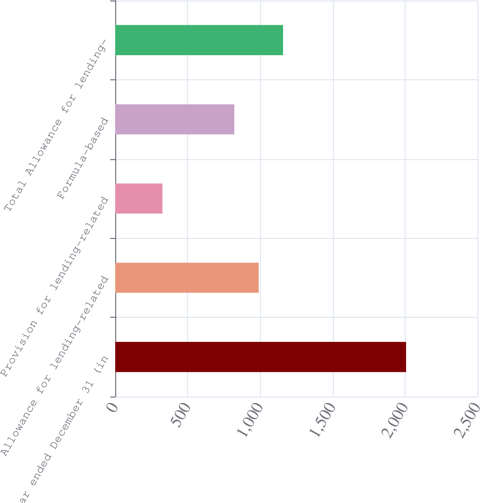

target table:
    TITLE |
    Year ended December 31 (in | 2007
    Allowance for lending-related | 990.1
    Provision for lending-related | 326
    Formula-based | 822
    Total Allowance for lending- | 1158.2
{'probe': 'duplicate id', 'rejected': "duplicate id 'same'"}
{'probe': 'missing image file', 'rejected': 'records[0]: image file not found: work/does-not-exist.png'}
{'probe': 'target without a table row', 'rejected': 'records[0]: target_text must hold at least one table row'}
{'probe': 'too small', 'rejected': '3 records; 8..5000 are required'}


In [ ]:
import collections
import hashlib
import io
import json
import shutil
import stat
import zipfile

from PIL import Image

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}
SPLIT_SEED = 42  # @param {type:"integer"}

MAX_ZIP_MEMBERS = 20_000
MAX_ZIP_BYTES = 2_000_000_000
RECORDS_NAMES = ('records.jsonl', 'records.json')


def show_chart(source, width=480):
    """Display a chart (an image or a path) scaled to at most `width` px wide."""
    chart = source.copy() if isinstance(source, Image.Image) else Image.open(source)
    chart = chart.convert('RGB')
    chart.thumbnail((width, width * 4))
    display(chart)


def show_table(label, text, limit=6):
    """Print a linearised table one row per line (at most `limit` rows), so it can be read beside its chart."""
    rows = [row.strip() for row in str(text).split(ROW_SEPARATOR)]
    print(f'{label}:')
    for row in rows[:limit]:
        print('    ' + row)
    if len(rows) > limit:
        print(f'    ... {len(rows) - limit} more rows')


def extract_zip(payload, root, label):
    """Extract an uploaded zip under root, keeping sub-folders and refusing the whole archive before writing anything unsafe."""
    base = root.resolve()
    try:
        archive = zipfile.ZipFile(io.BytesIO(payload))
    except zipfile.BadZipFile:
        raise ValueError(f'{label} is not a readable zip file: zip the records file and the images together and supply that zip.') from None
    with archive:
        members = archive.infolist()
        expanded = sum(m.file_size for m in members)
        if len(members) > MAX_ZIP_MEMBERS or expanded > MAX_ZIP_BYTES:
            raise ValueError(f'{label} holds {len(members)} members and expands to {expanded} bytes; the limits are {MAX_ZIP_MEMBERS} members and {MAX_ZIP_BYTES} bytes, checked before anything is written.')
        for member in members:
            if stat.S_ISLNK(member.external_attr >> 16):
                raise ValueError(f'{label}: zip member {member.filename!r} is a symbolic link, which is not accepted; nothing was extracted.')
            target = (root / member.filename).resolve()
            if target == base or not target.is_relative_to(base):
                raise ValueError(f'{label}: zip member {member.filename!r} would land outside the upload folder; nothing was extracted.')
        for member in members:
            if not member.is_dir():
                target = (root / member.filename).resolve()
                target.parent.mkdir(parents=True, exist_ok=True)
                target.write_bytes(archive.read(member))


def find_records_file(root, label):
    found = sorted(p for p in Path(root).rglob('*') if p.name in RECORDS_NAMES and '__MACOSX' not in p.parts)
    if not found:
        raise ValueError(f'No records.jsonl or records.json found in {label}. Put one records file of {{id, image, target_text}} objects beside the images (image paths relative to it), then run this cell again.')
    if len(found) > 1:
        raise ValueError(f'{label} holds more than one records file; keep exactly one of: ' + ', '.join(str(p.relative_to(root)) for p in found))
    return found[0]


os.makedirs('outputs', exist_ok=True)
byod = None
if USE_BYOD:
    byod_root = Path('work') / 'byod'
    if byod_root.exists():
        shutil.rmtree(byod_root)  # a new upload never reads files left by an earlier one
    byod_root.mkdir(parents=True)
    payload = None
    if BYOD_PATH.strip():
        source = Path(BYOD_PATH.strip()).expanduser()
        if not source.exists():
            raise FileNotFoundError(f'BYOD_PATH = {BYOD_PATH!r} does not exist in this runtime: fix the path, or leave BYOD_PATH empty to upload a zip in Colab.')
        file_name = source.name
        if source.is_dir():
            records_file = find_records_file(source, str(source))
        elif source.suffix.lower() == '.zip':
            payload = source.read_bytes()
            extract_zip(payload, byod_root, file_name)
            records_file = find_records_file(byod_root, file_name)
        else:
            raise ValueError(f'BYOD_PATH must name a .zip or a folder holding records.jsonl / records.json and the images, not {file_name!r}.')
    else:
        try:
            from google.colab import files
        except ImportError:
            raise RuntimeError('The upload dialog needs Google Colab. Elsewhere, put the zip (or folder) in this runtime and set BYOD_PATH to its path.') from None
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise RuntimeError(f'Upload exactly one .zip file (received {len(uploaded)}). Run this cell again and choose a file, or set BYOD_PATH to a zip or folder already in this runtime.')
        file_name, payload = next(iter(uploaded.items()))
        if not file_name.lower().endswith('.zip'):
            raise ValueError(f'Upload a .zip holding records.jsonl / records.json and the images, not {file_name!r}.')
        extract_zip(payload, byod_root, file_name)
        records_file = find_records_file(byod_root, file_name)
    records = load_byod_dataset(records_file)
    splits = split_dataset(records, seed=SPLIT_SEED, base_dir=records_file.parent)
    data_source = 'BYOD (' + file_name + ')'
    raw_rows = {'byod': len(records)}
    byod = {'file': file_name, 'records_file': records_file.name, 'records': len(records), 'zip_sha256': hashlib.sha256(payload).hexdigest() if payload is not None else None, 'record_limits': list(byod_record_limits())}
else:
    shard_path = fetch_corpus(cache_dir='weights/synthchartnet')
    corpus_rows = read_corpus(shard_path)
    raw_rows = {'charts': len(corpus_rows), 'chart_types': dict(collections.Counter(r['chart_type'] for r in corpus_rows))}
    example_row = next(r for r in corpus_rows if r['chart_type'] == 'stacked_bar')
    print({'otsl': example_row['otsl'][:220], 'target': target_from_otsl(example_row['otsl'])[:220]})
    splits = build_sample_dataset(corpus_rows, shard_path, seed=SPLIT_SEED, image_dir='weights/synthchartnet/images')
    data_source = f'{CORPUS_NAME} — {CORPUS_RELEASE}'
dataset_manifests = {name: validate_dataset(part, min_records=MIN_RECORDS if name == 'train' else 1) for name, part in splits.items()}
splits = {name: manifest['records'] for name, manifest in dataset_manifests.items()}
disjoint = check_split_disjoint(splits)
train_records, val_records, test_records = splits['train'], splits['validation'], splits['test']
chart_types = {name: manifest['chart_types'] for name, manifest in dataset_manifests.items()}
write_dataset_jsonl(splits['train'], 'outputs/deplot_chart_train.jsonl')
if USE_BYOD:
    print({'data_source': data_source, 'raw_rows': raw_rows, 'splits': disjoint, 'byod': byod})
else:
    print({'data_source': data_source, 'raw_rows': raw_rows, 'splits': disjoint, 'shard_sha256': str(CORPUS_FILE['sha256'])[:16] + '...'})
for name, manifest in dataset_manifests.items():
    print({name: {'charts': manifest['n_records'], 'images': manifest['unique_images'], 'chart_types': manifest['chart_types'], 'table_rows': manifest['table_rows'], 'table_columns': manifest['table_columns'], 'digest': manifest['digest'][:16] + '...'}})
example = splits['train'][0]
print({'example': {'id': example['id'], 'image': Path(example['image']).name, 'size': example['image_size'], 'chart_type': example['chart_type']}})
show_chart(example['image'])
show_table('target table', example['target_text'])

probes = {
    'duplicate id': [{**r, 'id': 'same'} for r in splits['train'][:8]],
    'missing image file': [{**splits['train'][0], 'image': 'work/does-not-exist.png'}, *splits['train'][1:8]],
    'target without a table row': [{**splits['train'][0], 'target_text': 'TITLE | nothing else'}, *splits['train'][1:8]],
    'too small': splits['train'][:3],
}
for name, probe in probes.items():
    try:
        validate_dataset(probe)
        print({'probe': name, 'verdict': 'accepted'})
    except (TypeError, ValueError) as exc:
        print({'probe': name, 'rejected': str(exc)[:110]})

**What to notice:** the three split sizes, the chart-type counts per split, the chart beside its target table, and that the splits share no image.

<details><summary>Check your reasoning</summary>One, or none. The split gives each chart type its share of the shard's mix, and 0.5 % of 160 is 0.8 charts, so in the recorded Kaggle T4 runs of the previous notebook version (same seed) the test split held bar 72, pie 73, stacked-bar 14 and line 1. A per-type score on a single line chart is one observation, not a measurement, and the 14 stacked-bar charts are only a little better: read the per-type breakdown for bars and pies, and treat the other two types as anecdotes.</details>

## 5. Extract a table through the inference contract

The inference contract is exercised as the inference-only tutorial exercised it: a bar chart drawn in code at 800×520 from the five-row table `EXPECTED_TABLE` — the title `Quarterly revenue 2025 (USD millions)`, a y axis from 0 to 200 with gridlines, four bars for Q1–Q4 with their values printed above them. The cell shows it. It is a different image family from the SynthChartNet charts, and the adapted model will extract it again in Section 9. `validate_inputs` applies exactly the checks `extract_table` applies (image sides `MIN_IMAGE_SIDE`..`MAX_IMAGE_SIDE`, `max_new_tokens` in `[1, MAX_NEW_TOKENS]`) and returns an input manifest; a zero budget is validated too and its rejection recorded as a finding. `extract_table` renders the fixed instruction as a header above the chart, cuts the composite into at most 2,048 **patches** (16×16-pixel squares, the encoder's input units), and returns `text` (the **linearised table** exactly as decoded: rows joined by the `<0x0A>` token, cells by `|`), the parsed `table`, `new_tokens`, a `truncated` flag that is true when the budget was exhausted, and the model identity. **No score exists.** `evaluation_report` scores it against the table you drew yourself — verdict `sample-sanity`, plumbing evidence, not a metric. The image digest depends on the Pillow build's bundled font rendering. On CPU this one extraction takes seconds; on a GPU, under a second.

**Every pass starts from the pretrained model.** Section 7 changes the model in memory. If this cell, Section 6 or Section 7 runs again after Section 7 (a BYOD run or one of the optional experiments), it first reloads the pretrained model from the verified snapshot with `reset_to_pretrained()`, so a *before* or *frozen* number is never read from the adapted model.

**Predict before running:** the chart's legend-free y axis is labelled only by its title. Which cells of `EXPECTED_TABLE` will the model get exactly right, and which header will it write for the value column?

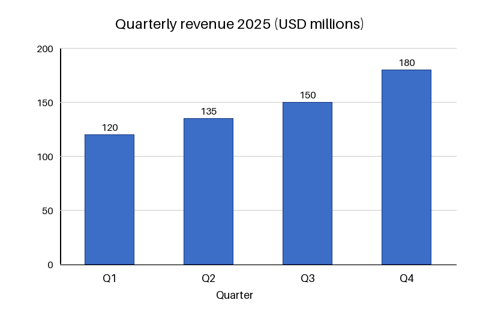

{'MIN_IMAGE_SIDE': 16, 'MAX_IMAGE_SIDE': 4096, 'MAX_PATCHES': 2048, 'MAX_NEW_TOKENS': 1024, 'DEFAULT_MAX_NEW_TOKENS': 512, 'MAX_TARGET_TOKENS': 512, 'MAX_TARGET_CHARS': 512, 'DECODING': 'greedy', 'INSTRUCTION': 'Generate underlying data table of the figure below:', 'ROW_SEPARATOR': '<0x0A>', 'CELL_SEPARATOR': '|', 'MIN_RECORDS': 8, 'MAX_RECORDS': 5000, 'MAX_EVAL_RECORDS': 500}
{'image': 'synthetic_bar_chart_800x520.png', 'rgb_sha256': '175a1e4d557e4065...', 'manifest_verdict': 'accepted', 'findings': 1}


TITLE | Quarterly revenue 2025 (USD millions) <0x0A> Quarter | Quarterly revenue <0x0A> Q1 | 120 <0x0A> Q2 | 135 <0x0A> Q3 | 150 <0x0A> Q4 | 180
extracted table:
    TITLE | Quarterly revenue 2025 (USD millions)
    Quarter | Quarterly revenue
    Q1 | 120
    Q2 | 135
    Q3 | 150
    Q4 | 180
{'checks': {'text_is_str': True, 'budget_respected': True, 'setting_echoed': True, 'not_truncated': True}, 'seconds': 6.499, 'new_tokens': 56, 'frozen_drawn_verdict': 'sample-sanity', 'cell_accuracy': 0.9, 'title_match': 1.0}


In [ ]:
import csv
import gc
import time

import numpy as np
from PIL import ImageDraw, ImageFont

TABLE_MAX_TOKENS = 512  # @param {type:"integer"}
PROGRESS_EVERY = 20  # charts between progress lines in Sections 6-8
CHART_TITLE = 'Quarterly revenue 2025 (USD millions)'
EXPECTED_TABLE = [['Quarter', 'Revenue'], ['Q1', '120'], ['Q2', '135'], ['Q3', '150'], ['Q4', '180']]


def reset_to_pretrained():
    """Sections 5-7 start from the pretrained model: if an earlier pass adapted `pipe`, reload it from the verified snapshot."""
    global pipe
    if pipe.adapter is None:
        return
    pipe = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    pipe = DePlotPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)
    print({'reloaded': 'the pretrained model, from the verified snapshot', 'reason': 'an earlier pass had adapted the model in memory'})


def chart_progress(label, every=PROGRESS_EVERY):
    """A progress callback for pipe.evaluate: one line every `every` charts and at the end, with the elapsed time."""
    started = time.perf_counter()

    def report(done, total):
        if done % every == 0 or done == total:
            print(f'  {label}: {done}/{total} charts, {time.perf_counter() - started:.0f} s')
    return report


def bar_chart(width=800, height=520):
    """Titled bar chart with a labelled y axis, gridlines, x labels and value labels, drawn from EXPECTED_TABLE."""
    img = Image.new('RGB', (width, height), 'white')
    d = ImageDraw.Draw(img)
    title_f, tick_f, label_f = ImageFont.load_default(size=24), ImageFont.load_default(size=16), ImageFont.load_default(size=18)
    d.text((width / 2 - d.textlength(CHART_TITLE, font=title_f) / 2, 24), CHART_TITLE, fill='black', font=title_f)
    x0, y0, x1, y1 = 100, 80, width - 40, height - 80
    d.line([(x0, y0), (x0, y1), (x1, y1)], fill='black', width=2)
    ymax = 200
    for v in range(0, ymax + 1, 50):
        y = y1 - (y1 - y0) * v / ymax
        d.line([(x0, y), (x1, y)], fill=(200, 200, 200), width=1)
        d.text((x0 - 12 - d.textlength(str(v), font=tick_f), y - 9), str(v), fill='black', font=tick_f)
    n = len(EXPECTED_TABLE) - 1
    slot = (x1 - x0) / n
    for i, (label, value) in enumerate(EXPECTED_TABLE[1:]):
        bx0 = x0 + slot * i + slot * 0.25
        bx1 = bx0 + slot * 0.5
        by = y1 - (y1 - y0) * int(value) / ymax
        d.rectangle([bx0, by, bx1, y1], fill=(60, 110, 200), outline=(20, 50, 120))
        d.text(((bx0 + bx1) / 2 - d.textlength(label, font=label_f) / 2, y1 + 12), label, fill='black', font=label_f)
        d.text(((bx0 + bx1) / 2 - d.textlength(value, font=tick_f) / 2, by - 22), value, fill='black', font=tick_f)
    d.text((width / 2 - 40, height - 40), 'Quarter', fill='black', font=label_f)
    return img


reset_to_pretrained()
image = bar_chart()
image_name = 'synthetic_bar_chart_800x520.png'
image_sha256 = hashlib.sha256(np.asarray(image.convert('RGB')).tobytes()).hexdigest()
show_chart(image)
ceilings = {'MIN_IMAGE_SIDE': MIN_IMAGE_SIDE, 'MAX_IMAGE_SIDE': MAX_IMAGE_SIDE, 'MAX_PATCHES': MAX_PATCHES, 'MAX_NEW_TOKENS': MAX_NEW_TOKENS, 'DEFAULT_MAX_NEW_TOKENS': DEFAULT_MAX_NEW_TOKENS, 'MAX_TARGET_TOKENS': MAX_TARGET_TOKENS, 'MAX_TARGET_CHARS': MAX_TARGET_CHARS, 'DECODING': DECODING, 'INSTRUCTION': INSTRUCTION, 'ROW_SEPARATOR': ROW_SEPARATOR, 'CELL_SEPARATOR': CELL_SEPARATOR, 'MIN_RECORDS': MIN_RECORDS, 'MAX_RECORDS': MAX_RECORDS, 'MAX_EVAL_RECORDS': MAX_EVAL_RECORDS}
print(ceilings)
input_manifest = validate_inputs(image, max_new_tokens=TABLE_MAX_TOKENS, names=[image_name])
try:
    validate_inputs(image, max_new_tokens=0)
except ValueError as exc:
    input_manifest['findings'].append({'input': 'zero-budget-probe', 'verdict': 'rejected', 'message': str(exc)})
with open('outputs/deplot_chart_input_manifest.json', 'w', encoding='utf-8') as handle:
    json.dump(input_manifest, handle, indent=2, ensure_ascii=False)
print({'image': image_name, 'rgb_sha256': image_sha256[:16] + '...', 'manifest_verdict': input_manifest['verdict'], 'findings': len(input_manifest['findings'])})
started = time.perf_counter()
result = pipe.extract_table(image, max_new_tokens=TABLE_MAX_TOKENS)
result_seconds = round(time.perf_counter() - started, 3)
print(result['text'])
show_table('extracted table', result['text'])
checks = {
    'text_is_str': isinstance(result['text'], str),
    'budget_respected': result['new_tokens'] <= TABLE_MAX_TOKENS,
    'setting_echoed': result['generation']['max_new_tokens'] == TABLE_MAX_TOKENS and result['generation']['do_sample'] is False,
    'not_truncated': not result['truncated'],
}
if not all(checks.values()):
    raise RuntimeError(f'extract_table output failed a sanity check: {checks}')
frozen_drawn = evaluation_report(result, EXPECTED_TABLE, expected_title=CHART_TITLE, sample_kind='synthetic')
print({'checks': checks, 'seconds': result_seconds, 'new_tokens': result['new_tokens'], 'frozen_drawn_verdict': frozen_drawn['verdict'], 'cell_accuracy': frozen_drawn['metrics'][0]['value'], 'title_match': frozen_drawn['metrics'][1]['value']})

**What to notice:** the decoded text with its `<0x0A>` row separators, the same table one row per line, `new_tokens` well under the budget, and that nothing in the output says how sure the model is.

<details><summary>Check your reasoning</summary>As recorded in the model card, the repository's CPU smoke on this chart generated 56 tokens: the title and all four quarters and values exactly, and the header `Quarter | Quarterly revenue` where the reference says `Revenue` — the model took the value column's name from the title. That one header cell is the miss, so cell accuracy is 0.9 (9 of 10 cells) and the title match 1.0; the recorded T4 runs gave the same 0.9. A confident, well-formed table with one wrong cell is exactly why a table is not evidence of its own correctness.</details>

## 6. Baselines and the frozen model on the test charts

Three references frame the adaptation, and none looks at the chart. The **empty baseline** emits no table (the floor: cell accuracy 0). The **header-only baseline** emits, per chart type, the most frequent header row of the training targets and no data rows — what a system that knows only the layout convention scores. The **medoid baseline** emits, per chart type, the training table that best matches the other training tables of its type (the *medoid*: the most typical member of a set). The **frozen model** extracts every test chart with the budget from Section 5 and is scored by `pipe.evaluate`: mean relaxed **cell accuracy** (position-wise, so a missing header row or a transposed table shifts every cell), **RNSS** (numbers only, layout-free), exact-table match and the truncation rate, overall and per chart type. SynthChartNet is not DePlot's training family and its targets follow the converter's layout rule, so expect the frozen model's cell accuracy well below its numbers on its own benchmarks; whether it beats the empty table is recorded as `frozen_beats_empty` rather than assumed. The cell reloads the pretrained model first if an earlier pass adapted it, and refuses to report an adapted model as frozen. It then shows one test chart of each type beside its target and the frozen model's table. No per-stage time is recorded for the T4 run (its whole default path took 4,794 s, fine-tuning 2,290 s of it); on CPU, 160 extractions are estimated at about 20 minutes at 24 threads and over an hour at 2. A progress line appears every 20 charts.

**Predict before running:** will the frozen model beat the medoid table on cell accuracy? Will it beat it by more, or by less, on RNSS?

{'baseline': 'empty', 'cell_accuracy': 0.0, 'rnss': 0.0, 'note': 'no table at all (the floor)'}
{'baseline': 'header-only', 'cell_accuracy': 0.007, 'rnss': 0.008, 'note': "the most frequent training header row of the chart's type, no data rows"}
{'baseline': 'medoid', 'cell_accuracy': 0.037, 'rnss': 0.172, 'note': "the training medoid table of the chart's type (highest mean cell accuracy against its type)"}


  frozen model, test split: 20/160 charts, 105 s


  frozen model, test split: 40/160 charts, 175 s


  frozen model, test split: 60/160 charts, 297 s


  frozen model, test split: 80/160 charts, 385 s


  frozen model, test split: 100/160 charts, 565 s


  frozen model, test split: 120/160 charts, 739 s


  frozen model, test split: 140/160 charts, 878 s


  frozen model, test split: 160/160 charts, 990 s


{'frozen_model_test': {'cell_accuracy': 0.16, 'rnss': 0.448, 'exact_table_match': 0.006, 'truncated_rate': 0.05}, 'n': 160, 'verdict': 'measured', 'adapted': False, 'seconds': 990.5}
{'by_chart_type': {'medoid': {'bar': {'n': 72, 'cell_accuracy': 0.0426, 'rnss': 0.1667, 'exact_table_match': 0.0}, 'line': {'n': 1, 'cell_accuracy': 0.375, 'rnss': 0.522, 'exact_table_match': 0.0}, 'pie': {'n': 73, 'cell_accuracy': 0.0179, 'rnss': 0.1637, 'exact_table_match': 0.0}, 'stacked_bar': {'n': 14, 'cell_accuracy': 0.083, 'rnss': 0.2117, 'exact_table_match': 0.0}}, 'frozen': {'bar': {'n': 72, 'cell_accuracy': 0.1478, 'rnss': 0.6095, 'exact_table_match': 0.0139}, 'line': {'n': 1, 'cell_accuracy': 0.375, 'rnss': 0.5729, 'exact_table_match': 0.0}, 'pie': {'n': 73, 'cell_accuracy': 0.1449, 'rnss': 0.293, 'exact_table_match': 0.0}, 'stacked_bar': {'n': 14, 'cell_accuracy': 0.2814, 'rnss': 0.4108, 'exact_table_match': 0.0}}}}
{'definitions': {'cell_accuracy': 'mean over charts of the relaxed position-wis

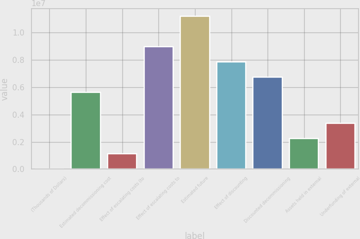

target:
    TITLE |
    (Thousands of Dollars) | 2015
    Estimated decommissioning cost | 5.60375e+06
    Effect of escalating costs (to | 1.12236e+06
    Effect of escalating costs to | 8.9648e+06
    Estimated future | 1.12055e+07
    ... 4 more rows
frozen model:
    TITLE |
    label | Value
    Intense (dozen) | 2000
    Intense communication set | 109510
    Intense domain record | 109510
    Intense resonance | 898910
    ... 6 more rows
--- line chart test-0072: frozen cell accuracy 0.375


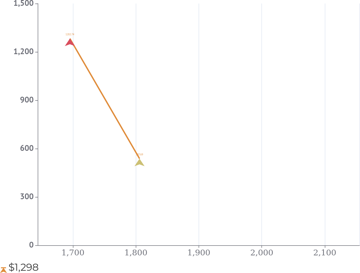

target:
    TITLE |
    | $1,298
    1695.23 | 1282.74
    1805.83 | 537.69
    2206.24 | 38.92
frozen model:
    TITLE |
    | Weight
    $1,298 | 1220
    $1,800 | 570
    $1,900 | 195
    $2,000 | 2050
    ... 1 more rows
--- pie chart test-0073: frozen cell accuracy 0.500


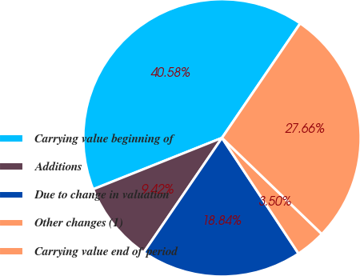

target:
    TITLE |
    Carrying value beginning of | 40.58%
    Additions | 9.42%
    Due to change in valuation | 18.84%
    Other changes (1) | 3.5%
    Carrying value end of period | 27.66%
frozen model:
    TITLE |
    Carrying value beginning of | 0.4258
    Additions | 0.0000
    Due to change in valuation | 0.0000
    Other changes (1) | 0.1884
    Carrying value end of period | 0.1884
    ... 1 more rows
--- stacked_bar chart test-0146: frozen cell accuracy 0.167


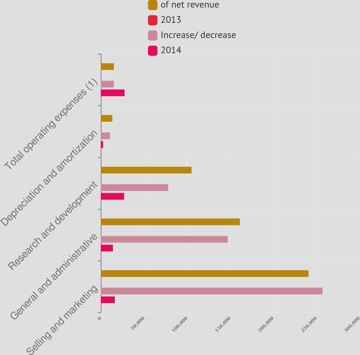

target:
    TITLE |
    | of net revenue | 2013 | Increase/ decrease | 2014
    Selling and marketing | 240996 | 10.2 | 257329 | 16333
    General and administrative | 161374 | 6.9 | 147260 | 14114
    Research and development | 105256 | 4.5 | 78184 | 27072
    Depreciation and amortization | 13359 | 0.6 | 10634 | 2725
    ... 1 more rows
frozen model:
    TITLE |
    | of net revenue | 2013 | Increase/ decrease | 2014
    General and marketing | 2.89 | 2.92 | 36.08 | 25.84
    Research and development | 2.95 | 2.91 | 19.99 | 23.58
    Depreciation and development | 2.71 | 2.71 | 16.09 | 2.06
    Total operating expenses (1) | 1.93 | 1.93 | 1.99 | 1.99
    ... 1 more rows
{'frozen_beats_empty': True, 'frozen_beats_medoid': True}


In [ ]:
reset_to_pretrained()
baseline_empty = empty_baseline(test_records)
baseline_header = header_only_baseline(train_records, test_records)
baseline_medoid = medoid_baseline(train_records, test_records)
for baseline in (baseline_empty, baseline_header, baseline_medoid):
    print({'baseline': baseline['baseline'], 'cell_accuracy': round(baseline['cell_accuracy'], 3), 'rnss': round(baseline['rnss'], 3), 'note': baseline['note']})
t0 = time.perf_counter()
frozen_test = pipe.evaluate(test_records, max_new_tokens=TABLE_MAX_TOKENS, progress=chart_progress('frozen model, test split'))
if frozen_test['adapted']:
    raise RuntimeError('Section 6 must score the pretrained model, but the model in memory is adapted. Restart the session and choose Run all.')
print({'frozen_model_test': {'cell_accuracy': round(frozen_test['cell_accuracy'], 3), 'rnss': round(frozen_test['rnss'], 3), 'exact_table_match': round(frozen_test['exact_table_match'], 3), 'truncated_rate': round(frozen_test['truncated_rate'], 3)}, 'n': frozen_test['n'], 'verdict': frozen_test['verdict'], 'adapted': frozen_test['adapted'], 'seconds': round(time.perf_counter() - t0, 1)})
print({'by_chart_type': {'medoid': baseline_medoid['by_chart_type'], 'frozen': frozen_test['by_chart_type']}})
print({'definitions': frozen_test['definitions']})
test_by_id = {r['id']: r for r in test_records}
shown_ids = []
for chart_type in sorted(frozen_test['by_chart_type']):
    row = next(r for r in frozen_test['rows'] if r['chart_type'] == chart_type)
    shown_ids.append(row['id'])
    print(f"--- {chart_type} chart {row['id']}: frozen cell accuracy {row['cell_accuracy']:.3f}")
    show_chart(test_by_id[row['id']]['image'], width=360)
    show_table('target', row['target_text'])
    show_table('frozen model', row['prediction'])
frozen_beats_empty = frozen_test['cell_accuracy'] > baseline_empty['cell_accuracy']
frozen_beats_medoid = frozen_test['cell_accuracy'] > baseline_medoid['cell_accuracy']
print({'frozen_beats_empty': frozen_beats_empty, 'frozen_beats_medoid': frozen_beats_medoid})

**What to notice:** `adapted: False`, the progress lines, the gap between the baselines and the frozen model on each metric, and the charts where the frozen table and the target differ in layout rather than in numbers.

<details><summary>Check your reasoning</summary>Yes on both, and by much more on RNSS. In the recorded Kaggle T4 runs of the previous notebook version the empty, header-only and medoid baselines scored cell accuracy 0.000 / 0.007 / 0.037 and the frozen model 0.160; its RNSS was 0.448 and its exact-table match 0.006. The gap is far wider on RNSS because the frozen model reads most of the numbers but often lays the table out differently from the converter's rule (a different header, a missing title row), and position-wise cell accuracy charges every shifted cell. That gap is what fine-tuning on the converter's targets can close — which is also why a later gain in cell accuracy may be layout rather than reading.</details>

## 7. Bounded fine-tuning of the decoder's last blocks

`pipe.adapt` trains only the last `TRAINABLE_DECODER_LAYERS` blocks of the text decoder plus the decoder's final layer norm — two blocks by default, 18,879,744 of 282,285,696 parameters; the image encoder, every embedding and the untied output projection stay frozen. Each training chart is one sample: the fixed instruction is rendered above the chart exactly as `extract_table` renders it, the frozen encoder reads the composite (recomputed each step without gradients), and the target is the tokenised linearised table (at most `MAX_TARGET_TOKENS` tokens) with its end-of-sequence token, decoded with **teacher forcing** (the decoder sees the correct previous tokens, not its own guesses) and scored with the model's own cross-entropy (padding ignored); AdamW at a fixed learning rate, gradient clipping at 1.0, seeded shuffling and no scheduler. Epoch 0 records the frozen model's validation metrics; every epoch is scored on the 80 validation charts and the epoch with the highest **validation** cell accuracy is kept (ties keep the earlier one) — the test split plays no part in that choice. If no epoch beats the frozen model on validation, the selector keeps epoch 0 and the adapter reproduces the frozen tables; that outcome is reported, not hidden. A progress line appears every 20 training or validation charts. The three epochs took 2,290 s on the T4 record; on CPU the default fine-tuning alone is estimated at well over an hour.

**Adaptation always starts from the pretrained model.** If this cell runs again (for example with `TRAINABLE_DECODER_LAYERS = 1` in Section 10), it first reloads the pretrained model from the verified snapshot, so the new training never stacks on the previous one, epoch 0 really is the frozen model, and the exported adapter holds exactly what this run trained; `pipe.adapt` itself refuses a model that is already adapted.

**Predict before running:** will validation cell accuracy rise in every epoch? Which epoch will be kept?

In [ ]:
EPOCHS = 3  # @param {type:"integer"}
LEARNING_RATE = 1e-5  # @param {type:"number"}
BATCH_SIZE = 4  # @param {type:"integer"}
TRAINABLE_DECODER_LAYERS = 2  # @param {type:"integer"}


def report(entry):
    row = {'epoch': entry['epoch'], 'train_loss': None if entry['train_loss'] is None else round(entry['train_loss'], 4)}
    if entry.get('val'):
        row.update({'val_cell_accuracy': round(entry['val']['cell_accuracy'], 3), 'val_rnss': round(entry['val']['rnss'], 3)})
    if 'note' in entry:
        row['note'] = entry['note']
    print(row)


def report_charts(entry, started=time.perf_counter()):
    if entry['charts'] % PROGRESS_EVERY < (BATCH_SIZE if entry['stage'] == 'train' else 1) or entry['charts'] == entry['of']:
        print(f"  epoch {entry['epoch']} {entry['stage']}: {entry['charts']}/{entry['of']} charts, {time.perf_counter() - started:.0f} s")


reset_to_pretrained()
t0 = time.perf_counter()
adapt_result = pipe.adapt(train_records, val_records, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, trainable_decoder_layers=TRAINABLE_DECODER_LAYERS, progress=report, chart_progress=report_charts)
adapt_seconds = round(time.perf_counter() - t0, 1)
print({'trainable_parameters': adapt_result['n_trainable'], 'total_parameters': adapt_result['n_total'], 'training_charts': adapt_result['n_train'], 'best_epoch': adapt_result['best_epoch'], 'selection': adapt_result['selection'], 'selection_split': 'validation', 'seconds': adapt_seconds})

  epoch 0 validation: 20/80 charts, 88 s


  epoch 0 validation: 40/80 charts, 240 s


  epoch 0 validation: 60/80 charts, 386 s


  epoch 0 validation: 80/80 charts, 472 s
{'epoch': 0, 'train_loss': None, 'val_cell_accuracy': 0.123, 'val_rnss': 0.48, 'note': 'frozen model'}


  epoch 1 train: 20/360 charts, 482 s


...

  epoch 3 train: 360/360 charts, 1834 s


  epoch 3 validation: 20/80 charts, 1951 s


  epoch 3 validation: 40/80 charts, 2086 s


  epoch 3 validation: 60/80 charts, 2157 s


  epoch 3 validation: 80/80 charts, 2237 s
{'epoch': 3, 'train_loss': 1.6535, 'val_cell_accuracy': 0.147, 'val_rnss': 0.478}
{'trainable_parameters': 18879744, 'total_parameters': 282285696, 'training_charts': 360, 'best_epoch': 2, 'selection': 'highest validation cell accuracy', 'selection_split': 'validation', 'seconds': 2236.7}


**What to notice:** epoch 0 is labelled the frozen model, how the training loss and the validation cell accuracy move from epoch to epoch, and which epoch is kept.

<details><summary>Check your reasoning</summary>Not necessarily. In the recorded Kaggle T4 runs of the previous notebook version the validation cell accuracy rose from 0.123 (epoch 0, the frozen model) to 0.162 at epoch 2, and epoch 3 did not beat it, so the selector kept epoch 2. The training loss keeps falling while the validation score levels off: the decoder fits the 360 training tables better than it generalises. Eighty validation charts give a noisy score, so one epoch's step up or down is not a trend. Had no epoch beaten epoch 0, the rule would have kept the frozen weights — a legitimate result, not an error.</details>

## 8. Held-out evaluation

The test charts were never used for training or epoch selection, and no test image appears in the training or validation splits. The adapted model is scored exactly as the frozen model was in Section 6, and the five systems — the three baselines, the frozen and the adapted model — are put side by side overall and per chart type. Read it in this order: **cell accuracy** first (the metric the epoch was selected on), then **RNSS** (an adaptation that only learns the target layout raises cell accuracy without reading the numbers any better; RNSS ignores layout), then exact-table match, then the per-type split — stacked-bar and line charts are a small share of the test split. The cell prints the three deltas and a reading keyed to their signs (a change smaller than 0.005 counts as flat), and keeps a **run history** for this session, one row per pass through Section 8, so an experiment can be compared with the default run (Section 10). `adapted_beats_frozen` records whether held-out cell accuracy rose; it is a cell-accuracy flag, not a verdict on every metric. The charts shown in Section 6 are shown again with the adapted table. A test split of 160 charts from one seeded draw of one shard gives **no dispersion estimate**, so the deltas are sample-sanity evidence that the adaptation contract works, not a benchmark, and a gain on SynthChartNet says nothing about your charts until you measure it there. This cell scores 240 charts (test and validation), half again as many as Section 6.

**Predict before running:** if cell accuracy rises, will RNSS rise with it? Will exact-table match?

  adapted model, test split: 20/160 charts, 132 s


  adapted model, test split: 40/160 charts, 196 s


  adapted model, test split: 60/160 charts, 269 s


  adapted model, test split: 80/160 charts, 370 s


  adapted model, test split: 100/160 charts, 500 s


...

  adapted model, test split: 160/160 charts, 885 s


  adapted model, validation split: 20/80 charts, 78 s


  adapted model, validation split: 40/80 charts, 225 s


  adapted model, validation split: 60/80 charts, 304 s


  adapted model, validation split: 80/80 charts, 385 s
{'cell_accuracy': {'empty': 0.0, 'header_only': 0.007, 'medoid': 0.037, 'frozen': 0.16, 'adapted': 0.181}}
{'rnss': {'empty': 0.0, 'header_only': 0.008, 'medoid': 0.172, 'frozen': 0.448, 'adapted': 0.447}}
{'exact_table_match': {'frozen': 0.006, 'adapted': 0.0}}
{'delta_vs_frozen': {'cell_accuracy': 0.021, 'rnss': -0.001, 'exact_table_match': -0.006}}
{'by_chart_type': {'bar': {'n': 72, 'medoid': 0.0426, 'frozen': 0.1478, 'adapted': 0.1726}, 'line': {'n': 1, 'medoid': 0.375, 'frozen': 0.375, 'adapted': 0.375}, 'pie': {'n': 73, 'medoid': 0.0179, 'frozen': 0.1449, 'adapted': 0.1663}, 'stacked_bar': {'n': 14, 'medoid': 0.083, 'frozen': 0.2814, 'adapted': 0.2857}}}
--- bar chart test-0000: cell accuracy 0.000 frozen -> 0.000 adapted


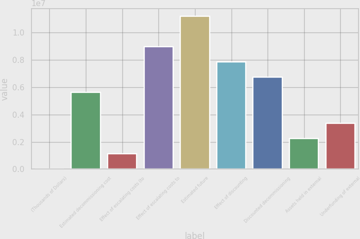

target:
    TITLE |
    (Thousands of Dollars) | 2015
    Estimated decommissioning cost | 5.60375e+06
    Effect of escalating costs (to | 1.12236e+06
    Effect of escalating costs to | 8.9648e+06
    Estimated future | 1.12055e+07
    ... 4 more rows
frozen model:
    TITLE |
    label | Value
    Intense (dozen) | 2000
    Intense communication set | 109510
    Intense domain record | 109510
    Intense resonance | 898910
    ... 6 more rows
adapted model:
    TITLE |
    label | Value
    Intense (26mm) | 156
    Intense communication ("Instrumental") | 1120110
    Intense division ("Instrumental") | 898789
    Entered message ("Entered message") | 1121411
    ... 4 more rows
--- line chart test-0072: cell accuracy 0.375 frozen -> 0.375 adapted


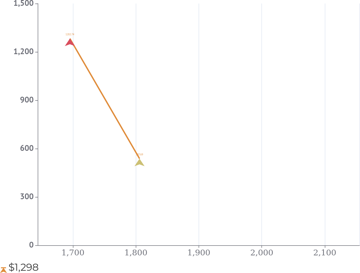

target:
    TITLE |
    | $1,298
    1695.23 | 1282.74
    1805.83 | 537.69
    2206.24 | 38.92
frozen model:
    TITLE |
    | Weight
    $1,298 | 1220
    $1,800 | 570
    $1,900 | 195
    $2,000 | 2050
    ... 1 more rows
adapted model:
    TITLE |
    | 1,700 | 1,800
    $1,298 | 1220 | 1000
    $1,800 | 570 | 368
    $1,700 | 1220 | 1000
--- pie chart test-0073: cell accuracy 0.500 frozen -> 0.500 adapted


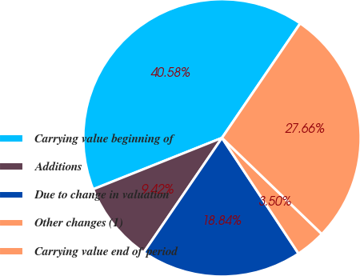

target:
    TITLE |
    Carrying value beginning of | 40.58%
    Additions | 9.42%
    Due to change in valuation | 18.84%
    Other changes (1) | 3.5%
    Carrying value end of period | 27.66%
frozen model:
    TITLE |
    Carrying value beginning of | 0.4258
    Additions | 0.0000
    Due to change in valuation | 0.0000
    Other changes (1) | 0.1884
    Carrying value end of period | 0.1884
    ... 1 more rows
adapted model:
    TITLE |
    Carrying value beginning of | 0.4258
    Additions | 0.0000
    Due to change in valuation | 0.0000
    Other changes (1) | 0.1884
    Carrying value end of period | 0.1884
--- stacked_bar chart test-0146: cell accuracy 0.167 frozen -> 0.167 adapted


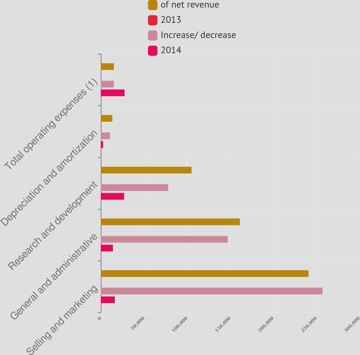

target:
    TITLE |
    | of net revenue | 2013 | Increase/ decrease | 2014
    Selling and marketing | 240996 | 10.2 | 257329 | 16333
    General and administrative | 161374 | 6.9 | 147260 | 14114
    Research and development | 105256 | 4.5 | 78184 | 27072
    Depreciation and amortization | 13359 | 0.6 | 10634 | 2725
    ... 1 more rows
frozen model:
    TITLE |
    | of net revenue | 2013 | Increase/ decrease | 2014
    General and marketing | 2.89 | 2.92 | 36.08 | 25.84
    Research and development | 2.95 | 2.91 | 19.99 | 23.58
    Depreciation and development | 2.71 | 2.71 | 16.09 | 2.06
    Total operating expenses (1) | 1.93 | 1.93 | 1.99 | 1.99
    ... 1 more rows
adapted model:
    TITLE |
    | of net revenue | 2013 | Increase/ decrease | 2014
    General and marketing | 2.86 | 2.80 | 36.08 | 28.83
    Research and development | 1.19 | 1.37 | 11.71 | 23.86
    Depreciation and development | 0.71 | 0.71 | 7.66 | 2.88
    Total operating expenses (1) | 1.19 | 0.70 | 1.32 | 2.88

In [ ]:
adapted_test = pipe.evaluate(test_records, max_new_tokens=TABLE_MAX_TOKENS, progress=chart_progress('adapted model, test split'))
adapted_val = pipe.evaluate(val_records, max_new_tokens=TABLE_MAX_TOKENS, progress=chart_progress('adapted model, validation split'))
comparison = {
    'cell_accuracy': {'empty': round(baseline_empty['cell_accuracy'], 3), 'header_only': round(baseline_header['cell_accuracy'], 3), 'medoid': round(baseline_medoid['cell_accuracy'], 3), 'frozen': round(frozen_test['cell_accuracy'], 3), 'adapted': round(adapted_test['cell_accuracy'], 3)},
    'rnss': {'empty': round(baseline_empty['rnss'], 3), 'header_only': round(baseline_header['rnss'], 3), 'medoid': round(baseline_medoid['rnss'], 3), 'frozen': round(frozen_test['rnss'], 3), 'adapted': round(adapted_test['rnss'], 3)},
    'exact_table_match': {'frozen': round(frozen_test['exact_table_match'], 3), 'adapted': round(adapted_test['exact_table_match'], 3)},
    'delta_vs_frozen': {'cell_accuracy': round(adapted_test['cell_accuracy'] - frozen_test['cell_accuracy'], 3), 'rnss': round(adapted_test['rnss'] - frozen_test['rnss'], 3), 'exact_table_match': round(adapted_test['exact_table_match'] - frozen_test['exact_table_match'], 3)},
    'by_chart_type': {chart_type: {'n': row['n'], 'medoid': baseline_medoid['by_chart_type'][chart_type]['cell_accuracy'], 'frozen': row['cell_accuracy'], 'adapted': adapted_test['by_chart_type'][chart_type]['cell_accuracy']} for chart_type, row in frozen_test['by_chart_type'].items()},
}
for key, row in comparison.items():
    print({key: row})
adapted_rows = {r['id']: r for r in adapted_test['rows']}
frozen_rows = {r['id']: r for r in frozen_test['rows']}
for chart_id in shown_ids:
    before, after = frozen_rows[chart_id], adapted_rows[chart_id]
    print(f"--- {before['chart_type']} chart {chart_id}: cell accuracy {before['cell_accuracy']:.3f} frozen -> {after['cell_accuracy']:.3f} adapted")
    show_chart(test_by_id[chart_id]['image'], width=360)
    show_table('target', before['target_text'])
    show_table('frozen model', before['prediction'])
    show_table('adapted model', after['prediction'])
adapted_beats_frozen = adapted_test['cell_accuracy'] > frozen_test['cell_accuracy']
deltas = comparison['delta_vs_frozen']


def direction(delta):
    return 'rose' if delta >= 0.005 else 'fell' if delta <= -0.005 else 'stayed flat'


moves = {metric: direction(adapted_test[metric] - frozen_test[metric]) for metric in ('cell_accuracy', 'rnss', 'exact_table_match')}
reading = f"cell accuracy {moves['cell_accuracy']} ({deltas['cell_accuracy']:+.3f}), RNSS {moves['rnss']} ({deltas['rnss']:+.3f}), exact-table match {moves['exact_table_match']} ({deltas['exact_table_match']:+.3f}). "
if adapt_result['best_epoch'] == 0:
    reading += 'The selector kept epoch 0, so the adapted model is the frozen model: no epoch beat it on validation.'
elif moves['cell_accuracy'] == 'rose' and moves['rnss'] != 'rose':
    reading += 'The gain is in layout - more cells in the expected positions - not in reading more numbers correctly, which RNSS would show.'
elif moves['cell_accuracy'] == 'rose':
    reading += 'Both rose, so at least part of the gain is in the numbers read, not only in the layout.'
elif moves['rnss'] == 'rose':
    reading += 'The numbers are read better but the layout is no closer to the targets.'
else:
    reading += 'Neither cell accuracy nor RNSS rose: this adaptation did not help on these test charts.'
print({'adapted_beats_frozen': adapted_beats_frozen, 'best_epoch': adapt_result['best_epoch']})
print('Reading: ' + reading)
run_history = globals().get('run_history', [])
run_history.append({'run': len(run_history) + 1, 'data': 'BYOD' if USE_BYOD else 'sample', 'layers': TRAINABLE_DECODER_LAYERS, 'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'best_epoch': adapt_result['best_epoch'], 'frozen_cell': round(frozen_test['cell_accuracy'], 3), 'adapted_cell': round(adapted_test['cell_accuracy'], 3), 'delta_cell': deltas['cell_accuracy'], 'delta_rnss': deltas['rnss']})
print(f"{'run':>3} {'data':>6} {'layers':>6} {'epochs':>6} {'lr':>8} {'best':>4} {'frozen':>7} {'adapted':>7} {'d_cell':>7} {'d_rnss':>7}")
for h in run_history:
    print(f"{h['run']:>3} {h['data']:>6} {h['layers']:>6} {h['epochs']:>6} {h['learning_rate']:>8g} {h['best_epoch']:>4} {h['frozen_cell']:>7.3f} {h['adapted_cell']:>7.3f} {h['delta_cell']:>+7.3f} {h['delta_rnss']:>+7.3f}")
evaluation_report_payload = {
    'model': {'id': MODEL_ID, 'revision': MODEL_REVISION, 'key': MODEL_KEY},
    'data_source': data_source,
    'dataset_digests': {name: manifest['digest'] for name, manifest in dataset_manifests.items()},
    'splits': disjoint,
    'chart_types': chart_types,
    'max_new_tokens': TABLE_MAX_TOKENS,
    'baselines': {'empty': baseline_empty, 'header_only': baseline_header, 'medoid': baseline_medoid},
    'frozen_test': frozen_test,
    'frozen_beats_empty': frozen_beats_empty,
    'frozen_beats_medoid': frozen_beats_medoid,
    'validation_metrics': adapted_val,
    'test_metrics': adapted_test,
    'comparison': comparison,
    'reading': reading,
    'adaptation': {k: v for k, v in adapt_result.items() if k not in ('history', 'trainable_names')},
    'history': adapt_result['history'],
    'adaptation_seconds': adapt_seconds,
    'adapted_beats_frozen': adapted_beats_frozen,
}
with open('outputs/deplot_chart_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report_payload, f, indent=2, ensure_ascii=False)
print({'report': 'outputs/deplot_chart_evaluation_report.json'})

**What to notice:** the delta row, the printed reading, the per-type line, the charts with three tables each, and the run history.

<details><summary>Check your reasoning</summary>Not in the recorded runs. On the Kaggle T4 runs of the previous notebook version cell accuracy rose 0.160 → 0.181 (+0.021) while RNSS stayed flat (0.448 → 0.447) and exact-table match fell from 0.006 to 0.000 (one chart of 160 to none). `adapted_beats_frozen` was `True`, but read with RNSS that is the *layout-learning* pattern: the adapted decoder writes tables shaped more like the converter's targets, so more cells land in the expected positions, while the set of numbers it reads is no better. So a `True` flag here does not mean the model reads charts better. Your run's reading line states your own numbers; write them down before Section 10.</details>

## 9. Re-extract the drawn chart, export the adapter and reload it

The drawn bar chart from Section 5 is extracted again by the adapted model and scored against the table you drew — a different image family from the SynthChartNet charts it was tuned on, and one with a title and a header the SynthChartNet targets never carry, so this is a small look at whether the adaptation changed the model's behaviour *outside* its sample (one chart of evidence, not a measurement; a different table here is a finding to record, not a failure). Both tables are written as CSV.

`pipe.save_artifact` writes the trained tensors — the decoder's last two blocks and its final layer norm by default, about 76 MB — as `adapter.safetensors`, with a `manifest.json` recording the artifact format, the base model id and revision, the digest of the base `model.safetensors`, the tensor names, the file size and SHA-256, the training configuration, the kept epoch and the epoch history (OUT8). An **adapter** is only the changed tensors; it is meaningless without the pinned base. `DePlotPipeline.from_artifact` re-verifies the base snapshot, checks the artifact manifest, its digest and its exact tensor set **before** deserialising, refuses any tensor that is not a decoder tensor, and overlays the tensors onto a freshly loaded base — a new object from files, not the in-memory model (VER2). The cell checks for identical tables on eight test charts (**reload parity**, VER4) and stops with an explanation if they differ. Under BYOD `result.json` records your upload in place of the SynthChartNet corpus block.

**Predict before running:** will the adapted model change the drawn chart's table, and will reload parity hold?

In [ ]:
adapted_result = pipe.extract_table(image, max_new_tokens=TABLE_MAX_TOKENS)
adapted_drawn = evaluation_report(adapted_result, EXPECTED_TABLE, expected_title=CHART_TITLE, sample_kind='synthetic')
show_table('frozen model', result['text'])
show_table('adapted model', adapted_result['text'])
print({'drawn_chart_cell_accuracy': {'frozen': frozen_drawn['metrics'][0]['value'], 'adapted': adapted_drawn['metrics'][0]['value']}})
with open('outputs/deplot_chart_table.csv', 'w', encoding='utf-8', newline='') as handle:
    writer = csv.writer(handle)
    writer.writerow(['model', 'row', 'cells'])
    for label, extracted in (('frozen', result), ('adapted', adapted_result)):
        for index, row in enumerate(extracted['table']['rows']):
            writer.writerow([label, index, ' | '.join(row)])

artifact_dir = Path('outputs/deplot_chart_adapter')
shutil.rmtree(artifact_dir, ignore_errors=True)
pipe.save_artifact(artifact_dir, metadata={'tutorial': 'deplot_chart', 'data_source': data_source})
artifact_manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
print({'artifact': str(artifact_dir), 'format': artifact_manifest['format'], 'tensors': len(artifact_manifest['tensors']), 'bytes': artifact_manifest['files'][0]['bytes'], 'sha256': artifact_manifest['files'][0]['sha256'][:16] + '...', 'best_epoch': artifact_manifest['adapter']['best_epoch']})

reloaded = DePlotPipeline.from_artifact(artifact_dir, weights_dir=WEIGHTS_DIR, device=pipe.device)
before = [r['text'] for r in pipe.predict(test_records[:8], max_new_tokens=TABLE_MAX_TOKENS)]
after = [r['text'] for r in reloaded.predict(test_records[:8], max_new_tokens=TABLE_MAX_TOKENS)]
parity = {'identical_tables': sum(a == b for a, b in zip(before, after, strict=True)), 'of': len(before)}
print({'reload_parity': parity, 'reloaded_best_epoch': reloaded.adapter['best_epoch']})
reloaded = None  # free the second copy of the model before any re-run
gc.collect()
if parity['identical_tables'] != parity['of']:
    raise RuntimeError(f'Reload parity failed: {parity}. The saved adapter does not reproduce the model that was evaluated in Section 8. Re-run from Section 7 (it reloads the pretrained model before adapting), or restart the session and choose Run all.')

weight_entry = next(entry for entry in MANIFEST['files'] if entry['path'] == WEIGHT_FILE)
result_payload = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model_id': MODEL_ID,
    'model_revision': MODEL_REVISION,
    'model_license': MODEL_LICENSE,
    'snapshot': {'path': str(WEIGHTS_DIR), 'files': snapshot['files'], 'total_bytes': snapshot.get('total_bytes'), 'fetched_this_run': fetched, 'weight_file': WEIGHT_FILE, 'weight_format': 'SafeTensors, loaded in float32, digest-verified', 'weight_sha256': weight_entry['sha256']},
    'data_source': data_source,
    'corpus': None if USE_BYOD else {'name': CORPUS_NAME, 'repo': CORPUS_REPO, 'revision': CORPUS_REVISION, 'release': CORPUS_RELEASE, 'license': CORPUS_LICENSE, 'file': CORPUS_FILE, 'sample_charts': SAMPLE_CHARTS, 'target_rule': 'bar, pie, stacked_bar transposed; line kept; TITLE row first'},
    'byod': byod,
    'splits': disjoint,
    'inference_contract': {'input_manifest': input_manifest, 'sanity_checks': checks, 'drawn_chart': {'name': image_name, 'size': list(image.size), 'rgb_sha256': image_sha256, 'expected_table': EXPECTED_TABLE, 'expected_title': CHART_TITLE}, 'frozen': {k: result[k] for k in ('text', 'new_tokens', 'truncated')}, 'frozen_report': frozen_drawn, 'adapted': {k: adapted_result[k] for k in ('text', 'new_tokens', 'truncated')}, 'adapted_report': adapted_drawn, 'seconds': result_seconds},
    'adaptation': {'best_epoch': adapt_result['best_epoch'], 'selection': adapt_result['selection'], 'learning_rate': LEARNING_RATE, 'epochs': EPOCHS, 'trainable_decoder_layers': TRAINABLE_DECODER_LAYERS, 'batch_size': BATCH_SIZE},
    'comparison': comparison,
    'reading': reading,
    'frozen_beats_empty': frozen_beats_empty,
    'frozen_beats_medoid': frozen_beats_medoid,
    'adapted_beats_frozen': adapted_beats_frozen,
    'artifact': {'dir': str(artifact_dir), 'sha256': artifact_manifest['files'][0]['sha256'], 'bytes': artifact_manifest['files'][0]['bytes'], 'tensors': len(artifact_manifest['tensors'])},
    'reload_parity': parity,
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'device': pipe.device, 'dtype': 'float32', 'source': pipe.source},
}
with open('outputs/deplot_chart_result.json', 'w', encoding='utf-8') as handle:
    json.dump(result_payload, handle, indent=2, ensure_ascii=False)
print(sorted(os.listdir('outputs')))

frozen model:
    TITLE | Quarterly revenue 2025 (USD millions)
    Quarter | Quarterly revenue
    Q1 | 120
    Q2 | 135
    Q3 | 150
    Q4 | 180
adapted model:
    TITLE | Quarterly revenue 2025 (USD millions)
    Quarter | Quarterly revenue
    Q1 | 120
    Q2 | 135
    Q3 | 150
    Q4 | 180
{'drawn_chart_cell_accuracy': {'frozen': 0.9, 'adapted': 0.9}}


{'artifact': 'outputs/deplot_chart_adapter', 'format': 'org.valcorza.deplot.adapter.v1', 'tensors': 29, 'bytes': 75522608, 'sha256': 'c04d63c375546183...', 'best_epoch': 2}


{'reload_parity': {'identical_tables': 8, 'of': 8}, 'reloaded_best_epoch': 2}


['deplot_chart_adapter', 'deplot_chart_evaluation_report.json', 'deplot_chart_input_manifest.json', 'deplot_chart_result.json', 'deplot_chart_table.csv', 'deplot_chart_train.jsonl']


**What to notice:** whether the drawn chart's table changed, the artifact's tensor count, size and kept epoch, and the reload-parity line.

<details><summary>Check your reasoning</summary>In the recorded Kaggle T4 runs of the previous notebook version the drawn chart's cell accuracy stayed 0.9 after adaptation — training on SynthChartNet's untitled tables did not break this one titled chart, which is one chart of evidence, not a measurement. The artifact held 29 tensors (two blocks of 14 plus the final layer norm, 75,522,608 bytes) and reload parity was 8/8: the exported adapter is the model that was evaluated. Parity holds because the adaptation started from the pretrained base, so the adapter carries every tensor that differs from it.</details>

## 10. Your turn — change one thing: train one decoder block instead of two

Optional; **Predict → Change → Run → Observe → Explain**. It retrains, so it takes about as long as Section 7 did (Section 7 alone took 2,290 s on the T4 record with two blocks; Sections 8 and 9 come on top; hours on CPU).

1. **Predict:** with `TRAINABLE_DECODER_LAYERS = 1` (half the trainable parameters), how big will the adapter be, will held-out cell accuracy and RNSS move more or less than in your default run, and will reload parity hold? Write your guesses next to the default run's row in the Section 8 run history.
2. **Change:** in Section 7 set `TRAINABLE_DECODER_LAYERS = 1`. Change nothing else.
3. **Run:** select the Section 7 cell and choose **Runtime → Run after**. Section 7 reloads the pretrained model before adapting, Section 8 compares against the same Section 6 frozen score and adds a row to the run history, and Section 9 exports and reloads the new adapter.
4. **Observe:** in Section 7, epoch 0 shows the *frozen* validation cell accuracy again (in the recorded T4 runs 0.123), not the adapted one — the sign that the model was reset; read the trainable-parameter count. In Section 8, compare the two rows of the run history and the reading line. In Section 9, read the tensor count, the bytes and the reload parity.
5. **Explain:** in one or two sentences, what did halving the trainable blocks change in the adapter and in the held-out deltas, and does the difference between the two runs exceed what one seeded split of 160 charts can resolve?

<details><summary>Check your reasoning</summary>Some answers are fixed by the design: the adapter holds 15 tensors (one block of 14 plus the final layer norm) and 9,440,256 trainable parameters, 37,762,904 bytes — about half the default's 75.5 MB (measured in a local CPU check with the pinned weights) — and reload parity holds because Section 7 started from the pretrained model, so the adapter carries every changed tensor. (Before this notebook reset the model, the same experiment trained on top of the first run, exported only the last block, and failed reload parity.) The held-out deltas are *your* result: read the two run-history rows side by side, check RNSS as well as cell accuracy, and remember that with no dispersion estimate a difference of a few thousandths between the two runs is not evidence that one setting is better.</details>

## Interpretation and limits

The frozen model is a plot-to-table translator scored on charts of a family it was not fine-tuned on, beside three baselines that never look at the chart, and a bounded fine-tuning of the decoder's last two blocks on a few hundred charts is then scored on a held-out test split — overall and per chart type — with an adapter that reloads to identical tables. That is the claim: the adaptation contract works end to end on a real labelled chart corpus, and the numbers it produces are read against the baselines and the frozen model rather than in isolation. Whether held-out cell accuracy rose is recorded as `adapted_beats_frozen`, not assumed, and Section 8 prints what the three deltas together say.

Cell accuracy is position-wise, so part of any gain can be the model learning the converter's layout — no header row for a single unnamed series, the transposed stacked bars — rather than reading values better; RNSS, which ignores layout, is the check on that, and in the recorded runs it did not move. The test split is 160 charts from one seeded draw of one shard, the validation split that picks the epoch is 80, stacked-bar and line charts are a small share of both, and SynthChartNet carries some label noise. **The model generates a table for any image**: an image that is not a chart produces a confident fabrication rather than an empty result, and `truncated` is the only structural flag you get. Fine-tuning on a narrow sample can also erode the model elsewhere; the drawn chart re-extracted in Section 9 is one chart of evidence about that, not a measurement.

Three things to carry to real data. **Baselines first:** the empty, header-only and medoid tables on *your* charts are the numbers to read before any model's, per chart type. **Layout is part of the target:** decide your table orientation and header rule once, from what the frozen model emits, and convert every label to it — a transposed target scores as a miss on every cell. **Leakage:** keep every record of a chart in one split (the contract does this) and split by source document when your charts come from few reports.

Successful execution proves that the recorded repository revision's pipeline modules, carried in this standalone notebook, can acquire and digest-verify the pinned model snapshot, fetch and digest-verify a real labelled chart corpus, validate the demonstrated dataset contract without leakage, execute the inference contract and a bounded fine-tuning, evaluate against three trivial baselines and the frozen model on a held-out split, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, accuracy on any other chart population, or production fitness.

**Optional experiments (they do not affect the default path).** Each one changes one thing; note the numbers you want to compare first (the Section 8 run history keeps one row per pass). In Colab, **Runtime → Run after** runs the selected cell and every cell below it; Sections 5, 6 and 7 reload the pretrained model before they use it, so no experiment inherits an earlier adaptation.

- **Fewer trainable blocks:** Section 10.
- **A higher learning rate:** set `LEARNING_RATE = 1e-4` in Section 7, select Section 7 and choose **Run after**. What happens to the training loss and to the validation cell accuracy, and which epoch does the selector keep?
- **More epochs:** set `EPOCHS = 5` in Section 7, select Section 7 and choose **Run after**. Does validation cell accuracy keep rising after the default's kept epoch, and does RNSS follow it?
- **Another split:** change `SPLIT_SEED` in Section 4, select Section 4 and choose **Run after**. How far do the frozen and adapted scores move with a different draw of 160 test charts — more or less than the default run's delta?
- **Unlabelled bars:** in Section 5 delete the line in `bar_chart` that draws the value above each bar, then run Section 5 only. How many of the four values does the model still recover from the bar heights and the axis?
- **Your own charts:** BYOD (Section 4, then **Run after**). Before the adapted number, how do the three baselines and the frozen model score on your charts, per chart type?

## Troubleshooting

- **Section 1 stops with "needs a Linux x86_64 runtime".** The locked environment is built from manylinux wheels. Use Google Colab, Kaggle or a Linux Jupyter server; Windows and macOS kernels are not supported.
- **Section 1 fails while downloading** (`uv` wheel, Python build or packages). The runtime needs PyPI and the python-build-standalone download; run the cell again once the network is back. A "size/SHA-256" or "does not match its digest" error means a file was altered: do not edit the cell, regenerate the notebook from the repository.
- **The run is very slow, or the session ends before Section 9.** On CPU the default path takes hours (Prerequisites). Switch to a GPU runtime (**Runtime → Change runtime type**) and choose **Run all** again; the progress lines in Sections 6–8 show how far a long stage has got.
- **"The isolated environment's Python process exited".** Usually the runtime ran out of memory (the model is 1.13 GB in float32, and Section 9 briefly holds two copies). Restart the session and choose **Run all**; on CPU, close other notebooks first. A CUDA out-of-memory error in Section 7 can be avoided with `BATCH_SIZE = 2`.
- **Out of disk, or a download stops.** The locked install, the 1.13 GB checkpoint and the 516 MB shard need several GB of free space. Start a fresh runtime, or delete `dimer_isolated_env/` and `weights/` from an earlier attempt.
- **A digest or size mismatch in Section 3 or 4.** A download was incomplete or altered; the notebook refuses it rather than continuing. Run the cell again; never edit the manifest or the corpus pins.
- **BYOD is refused in Section 4.** The message names what to fix: a split with too few or too many records (12 to 2,502 records, one per chart image), no or several records files, an image path that does not exist relative to the records file, a target with no table row or over 512 characters, a duplicate id, a zip over the member or size limit, or a member outside the upload folder. Fix the zip and run Section 4 with **Run after** again. An empty or cancelled upload, or a runtime without the Colab upload dialog, asks you to choose a file or set `BYOD_PATH`.
- **Section 8 reads "The selector kept epoch 0" or "did not help".** Not an error: under these settings no adaptation beat the frozen model on validation, or the kept epoch did not beat it on test. Read the epoch history in Section 7; the export and reload in Section 9 still run.
- **Reload parity fails in Section 9.** The saved adapter does not reproduce the evaluated model. Re-run from Section 7 (it reloads the pretrained model first), or restart the session and choose **Run all**.
- **Numbers differ slightly from the recorded runs.** CPU and GPU arithmetic differ, and because decoding is autoregressive one different token changes the rest of a table; differences of a few thousandths between a T4 and a CPU run are expected. Larger differences on the default settings mean a form field was changed.
- **You re-ran the routing cell in Section 1.** It starts a new isolated process and discards every variable created so far; choose **Run all** again.

## Glossary

- **Linearised table:** a table written as one string — `TITLE | <title>` first, rows joined by the `<0x0A>` token (a newline written as a byte token) and cells by ` | `. It is what DePlot generates and what the targets use.
- **OTSL:** the corpus's table markup, one token per cell; the carried converter turns it into a linearised table.
- **Rendered header:** the fixed instruction drawn as text above the chart, so the model reads the prompt as pixels (the Pix2Struct VQA convention).
- **Patches:** the 16×16-pixel squares the encoder reads; a chart is resized to at most 2,048 of them.
- **Greedy decoding / token budget:** generating each next token as the single most likely one, up to `max_new_tokens`; `truncated` says the budget ran out. Reproducible, not a quality guarantee.
- **Cell accuracy (relaxed, position-wise):** the share of target cells matched by the predicted cell at the same row and column, numbers within 5 %.
- **RNSS:** relative number set similarity — how closely the set of numbers in the prediction matches the target's, ignoring where they are.
- **Exact-table match:** the prediction equals the target table cell for cell.
- **Baseline (empty / header-only / medoid):** systems that never see the chart, showing what any useful model must beat; the medoid is the most typical training table of a chart type.
- **Fine-tuning / trainable blocks:** further training on labelled examples; only the named decoder blocks may change, the rest stay frozen.
- **Teacher forcing:** during training the decoder is fed the correct previous tokens of the target, not its own predictions.
- **Epoch / validation selection:** one pass over the training charts; the epoch kept is the one with the highest validation cell accuracy (epoch 0 = the frozen model).
- **Training / validation / test split:** charts used to train, to choose the epoch, and to report the final result once; split by chart image so no image is in two splits.
- **Adapter / reload parity:** the saved trained tensors, and the check that a pipeline rebuilt from them and the pinned base gives the same tables.

## Conclusion (your notes)

Optional personal notes, not a required submission. Complete each sentence from your own run:

- The task: from ___ to ___. On the test charts the medoid baseline reached a cell accuracy of ___, the pretrained model ___ and the adapted model ___ (kept epoch ___).
- RNSS moved from ___ to ___, so the change in cell accuracy reflects ___ (layout / reading / both).
- One failure mode I saw in the charts shown: ___. The chart types with too few test charts to judge were ___.
- Training one block instead of two (Section 10) changed ___; the difference between the runs is / is not larger than one seeded split can resolve, because ___.
- Before trusting this adaptation on my own charts I would measure ___ on ___, with the baselines first.

## References

- Repository README: https://github.com/kurtvalcorza/deplot-chart-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/deplot-chart-pipeline/blob/main/MODEL_CARD.md
- Weight provenance: https://github.com/kurtvalcorza/deplot-chart-pipeline/blob/main/docs/WEIGHTS.md
- Upstream model (Google, Apache-2.0): https://huggingface.co/google/deplot
- Upstream code: https://github.com/google-research/pix2struct
- DePlot: One-shot visual language reasoning by plot-to-table translation (Liu et al., 2022): https://arxiv.org/abs/2212.10505
- Pix2Struct: Screenshot Parsing as Pretraining for Visual Language Understanding (Lee et al., ICML 2023): https://arxiv.org/abs/2210.03347
- ChartQA: A Benchmark for Question Answering about Charts with Visual and Logical Reasoning (Masry et al., 2022): https://arxiv.org/abs/2203.10244
- SynthChartNet (docling-project, CDLA-Permissive-2.0): https://huggingface.co/datasets/docling-project/SynthChartNet
- DIMER Notebook Specification 2.2 and Model Card Specification 1.1 (fleet specs in the ml-worker repository)